# Requirements check

In [1]:
import sys
print(sys.version)

3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]


# Install dependencies

In [3]:
# cell A: which Python executable and environment
import sys, os
print("sys.executable:", sys.executable)
print("sys.version:", sys.version.replace('\n',' '))
print("PATH contains CUDA:", any("CUDA" in p or "cudnn" in p.lower() for p in os.environ.get("PATH","").split(os.pathsep)))


sys.executable: C:\Users\omirz\anaconda3\envs\sber_inputs\python.exe
sys.version: 3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:16) [MSC v.1916 64 bit (AMD64)]
PATH contains CUDA: True


In [4]:
# cell B: torch diagnostics (safe if torch absent)
try:
    import torch
    print("torch.__version__:", torch.__version__)
    print("torch.version.cuda:", torch.version.cuda)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    print("cuda device count:", torch.cuda.device_count())
    if torch.cuda.is_available():
        print("device name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("import torch failed / torch not found:", e)


torch.__version__: 2.5.1
torch.version.cuda: 12.1
torch.cuda.is_available(): True
cuda device count: 1
device name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [5]:
import torch

torch.cuda.is_available()

True

In [1]:
!pip install -r requirements.txt

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0rc1 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


## Imports

In [2]:
from utils.constants import (
    CATEGORY_MAP,
    BEST_PREDICTORS_FOR_INDEX
)
from utils.utils import (
    plot_known_feature_value,
    plot_graphics_for_each_ts,
    get_month_beginnings
)
import numpy as np
from utils.parametrized_values import (
    form_df_future,
    load_models,
    form_input_to_forecasting,
    train_model_and_eval_res,
    get_prediction_for_ts,
    df_combined,
    macro_data
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings('ignore')

Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб./кг', 'Огурцы тепличные, руб.

---
## TODO

Важные общие замечания:
1) делаем на python 3.9.7 сразу, чтобы у СБЕРа не было траблов с установкой (если что-то не получится, то проблем другую версию, но лучше, чтобы у них запустились) 
2) Им нужна возможность задавать больше 1го Инпута. Причем, лучше хуево, чем этого функционала вообще не будет. 
3) Прогнозируем мы все ряды (в том числе макро) 
4) В ряду, который является инпутом на визуализации надо подменять независимый прогноз на введённые значения (сейчас этого нет) 
5) Возможно стоит сделать проще и убрать часть предикторов - это довольно сложный функционал, который может расшатывать модель. 
6) Лучше сделать так, чтобы мы задавали только будущее значение и дату, а пропуск между последним доступным значением ряда заполнялся автоматом линейно. 


Общая архитектура: 
0) Датасеты - макро и отрасли (совмещённый АПК и Химия)
1) Общая предобработка - выделение кластеров (скрытая - просто забираем json )

2) Свёртка кластеров в индексы
3) Прогноз индексов и макро параметров
4) Расшивка индексов

Описание архитектуры отдельных частей: 
2) Свёртка кластеров в индексы - 
сначала нормализуешь ряды в кластере, потом берешь среднее по ним. Все

3) Прогноз индексов и макро: 
Сценарий 1: (univariate модель)
Каждый индекс или макро предсказывается своей моделью. Для индексов макропараметры являются past _covariates. 

Макропараметры можно предсказывать отдельно друг от друга, либо тоже добавлять в ковариаты друг другу - как выйдет, но лучше второе. 

Сценарий 2: (многомерная модель tft, Хронос или Random Forest) 
В этом случае мы учим ОДНУ модель для индексов и макро. 

Либо учим отдельно модель для макро, а их прогноз используем для Второй модели индексов как past_covariates. 

Не надо плодить на каждый ряд свою модель. 

Предикторы можно даже не использовать. 

4) Расшивка: 
Сценарий1: смотрим какие процентные изменения в прогнозе на индекс. Переносим такие же на сам ряд (можно даже обратную нормализацию не делать в таком случае) 

Сценарий 2: Можно то же самое сделать через линейную регрессию ряда по индексу. 

Сценарий 3: 
Простенькая multivariate модель для каждого кластера, в которую мы запихивает прогноз индекса как future covariate (но это не обязательно)

Лучше сделать сначала по 1му сценарию. Потом допилим остальное, если будет возможность.

---
## Global parameters setting

In [3]:
print(f"Available columns to predict: {df_combined.columns}, {macro_data.columns}")

Available columns to predict: Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       ...
       'Апатитовый концетрат (FOB Morocco)_norm',
       'Аммиак (FOB Черное море)_norm',
       'Аммиачная селитра (FOB Черное море)_norm',
       'Хлорид калия (CFR Ю-В Азия)_norm',
       'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия_norm',
       'Метанол_norm', 'Бензол, CFR Япония_norm', 'Этилен, CFR Китай_norm',
       'Удобрения и агрохимикаты_norm_sum', 'Органические химикаты_norm_sum'],
      dtype='object', length=110), Index(['Инфляция - Рост индекса цен производителей (RUB, eop PPI),',
       'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),',
       'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),',
      

## Описание параметров запуска

### Основные параметры прогнозирования
- `PREDICTION_HORIZON = 12` - горизонт прогнозирования (месяцев)
- `PREDICTOR_LAG = 12` - лаг предикторов

### Режимы работы и даты
- `IS_BACKTEST: bool = True` - режим бэктеста (True - тестирование на исторических данных, False - реальный прогноз)
- `BACKTEST_DATE` - дата начала бэктеста
- `SINGLE_DATAPOINT_TO_PRED = "2026-04-14"` - целевая дата для прогноза

### Параметры моделей
- `TARGET_COL_SUFFIX = "_sum"` - суффикс целевой переменной
- `MODEL_NAME_FOR_FORECASTER = "nbeats"` - тип модели для прогнозирования
- `USE_FUTURE_COV` - использование будущих ковариат (автоматически определяется по типу модели)

### Временные параметры
- `FUTURE_DATE` - будущая дата значений
- `train_end` - конец обучающего периода
- `past_idx` - даты исторических данных для обучения
- `future_idx` - даты будущего периода для прогноза

### Параметры внешних факторов
- `FUTURE_FORECASTER_TS_NAME = "Инфляция, г/г"` - название макроэкономического показателя
- `FUTURE_FORECASTER_TS_VALUES` - известные будущие значения макропоказателя

### Управление моделями
- `MODEL_SAVE_PATH` - шаблон пути для сохранения моделей
- `PERSIST_MODEL = True` - флаг сохранения моделей на диск
- `REFIT_MODEL = True` - флаг переобучения моделей

In [4]:
SINGLE_DATAPOINT_TO_PRED = "2026-05-01"

IS_BACKTEST: bool = df_combined.index[-1] >= pd.to_datetime(SINGLE_DATAPOINT_TO_PRED)
BACKTEST_PREDICTION_RANGE = 36 if IS_BACKTEST else 0

new_dates = pd.date_range(start=df_combined.index[-1] + pd.DateOffset(months=1),
                      end=SINGLE_DATAPOINT_TO_PRED,
                      freq='MS') if not IS_BACKTEST else \
            pd.date_range(start=pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE) + pd.DateOffset(months=1),
                      end=SINGLE_DATAPOINT_TO_PRED,
                      freq='MS')

PREDICTION_HORIZON = len(new_dates) if not IS_BACKTEST else BACKTEST_PREDICTION_RANGE

FUTURE_VALUES = {
    # "Кукуруза": 0.0,
    # "Пшеница 1-го класса": 0.0,
    # "Пшеница 3-го класса": 0.0,
    # "Пшеница 4-го класса": 0.0,
    # "Пшеница 5-го класса": 0.0,
    # "Пшеница 12,5% FOB Ново, $ т": 0.0,
    "Подсолнечник": 22.1,
    # "Соя": 0.0,
    # "Рапс, руб. т": 0.0,
    # # Oils & Meals
    # "Подсолнечное масло наливом (мировые цены)": 0.0,
    # "Бутилированное подсолнечное масло (рафинированное)": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, нерафинированное ": 0.0,
    # "Подсолнечное масло (наливом) не бутилированное, не": 0.0,
    # "Подсолнечный шрот ": 0.0,
    # "Соевое масло": 0.0,
    # "Соевый шрот": 0.0,
    # "Рапсовое масло EU, $ т": 0.0,
    # "Кокосовое масло ": 0.0,
    # "Пальмовое масло ": 0.0,
    # # Livestock
    # "Молоко сырое": 0.0,
    # "Мясо птицы бройлеров в живом весе ": 0.0,
    # "Мясо крупного рогатого скота в живом весе ": 0.0,
    # "Свинина в живом весе": 0.0,
    # "Баранина в живом весе": 0.0,
    # "Баранина в убойном весе ": 0.0,
    # "Яйцо товарное": 0.0,
    # # Processed meat
    # "Колбасы сырокопченые": 0.0,
    # "Колбасы вареные": 0.0,
    # # Fish
    # "Минтай б г, Владивосток руб. кг": 0.0,
    # "Минтай б г, Китай C&F $ т": 0.0,
    # "Сельдь н р, Владивосток руб. кг": 0.0,
    # # Vegetables
    # "Огурцы тепличные, руб. кг": 0.0,
    # "Томаты тепличные, руб. кг": 0.0,
    # # Other
    # "Сахар (средняя цена по России)": 0.0,
    # "Мука пшеничная, руб. т": 0.0,
    # # Stimuli crops
    # "Какао-бобы": 0.0,
    # "Табак": 0.0,
    # # Chemicals - dip
    # "Карбамид (FOB Южный)": 0.0,
    # "Моноаммонийфосфат, MAP (FOB Балтика)": 0.0,
    # "Апатитовый концетрат (FOB Morocco)": 0.0,
    # "Аммиак (FOB Черное море)": 0.0,
    # "Аммиачная селитра (FOB Черное море)": 0.0,
    # "Хлорид калия (CFR Ю-В Азия)": 0.0,
    # # Chemicals - bump
    # "Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия": 0.0,
    # "Метанол": 0.0,
    # "Бензол, CFR Япония": 0.0,
    # "Этилен, CFR Китай": 0.0,
    # # macros
    # "Инфляция - Рост индекса цен производителей (RUB, eop PPI),": 0.0,
    # "Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),": 0.0,
    # "Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),": 0.0,
    "Ключевая ставка, годовых": 18.0,
    "Инфляция, г/г": 12.0,
    # "USDRUB": 0.0
}
FUTURE_FORECASTER_TS_NAME = list(FUTURE_VALUES.keys())  # ["Подсолнечник", "Ключевая ставка, годовых", "Инфляция, г/г"]
FUTURE_FORECASTER_TS_VALUES_RAW = list(FUTURE_VALUES.values())

BACKTEST_DATE = df_combined.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON*2)
TS_FREQUENCY = "MS"
train_end = BACKTEST_DATE if not IS_BACKTEST else pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE)

if IS_BACKTEST:
    past_idx = pd.date_range(start=pd.to_datetime(SINGLE_DATAPOINT_TO_PRED) - pd.DateOffset(months=BACKTEST_PREDICTION_RANGE*2) + pd.DateOffset(months=1),
                               periods=PREDICTION_HORIZON,
                               freq=TS_FREQUENCY)
    future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                               periods=PREDICTION_HORIZON,
                               freq=TS_FREQUENCY)
else:
    past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)
    future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON,
                           freq=TS_FREQUENCY)

PERSIST_MODEL = True
REFIT_MODEL = True

PREDICTOR_LAG = 12
MODEL_SAVE_PATH = "{model_name}_dataset/{model_name}_for_{category_name}" + f"_{BACKTEST_PREDICTION_RANGE}" if IS_BACKTEST else  "{model_name}_dataset/{model_name}_for_{category_name}"
TARGET_COL_SUFFIX = "_norm_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "nbeats", "naiveseasonal", "randomforest"] = "randomforest"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel", "randomforest", "chronos")

if IS_BACKTEST:
    df_updated = df_combined
    macro_updated = macro_data
    FUTURE_FORECASTER_TS_VALUES = []
    for (ts_name, ts_val) in zip(FUTURE_FORECASTER_TS_NAME, FUTURE_FORECASTER_TS_VALUES_RAW): # TODO: rewrite to np.linnspace
        df_target = df_updated if ts_name in df_updated.columns else macro_updated
        df_target.loc[df_target.index > train_end, ts_name] = np.linspace(df_target[df_target.index == train_end].iloc[0][ts_name], ts_val, PREDICTION_HORIZON)
        FUTURE_FORECASTER_TS_VALUES.append(df_target[df_target.index > train_end][ts_name].values)
else:
    df_updated, macro_updated, FUTURE_FORECASTER_TS_VALUES = form_df_future(new_dates,
                                                                           FUTURE_FORECASTER_TS_NAME,
                                                                           FUTURE_FORECASTER_TS_VALUES_RAW,
                                                                           PREDICTION_HORIZON
                                                                       )

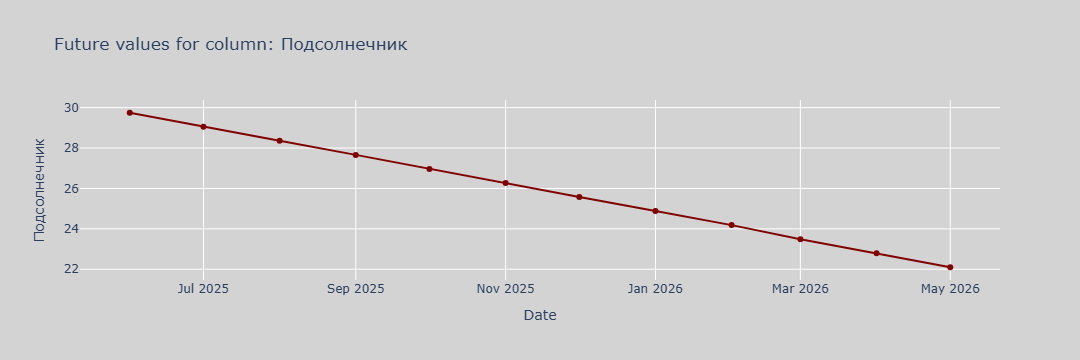

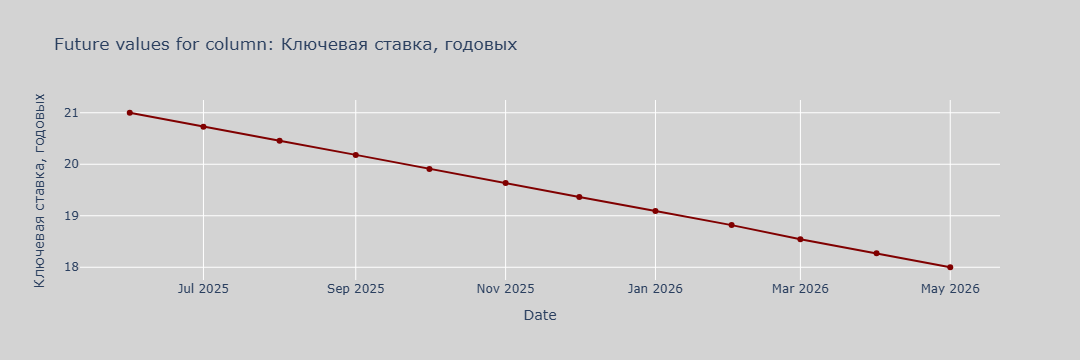

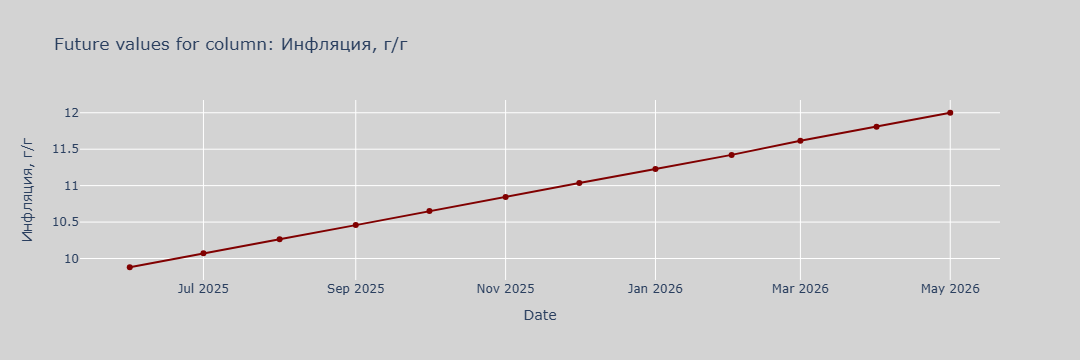

In [5]:
for ts_name, ts_val in zip(FUTURE_FORECASTER_TS_NAME, FUTURE_FORECASTER_TS_VALUES):
    plot_known_feature_value(ts_val,
                             ts_name,
                             pd.date_range(start=new_dates[0],
                               periods=PREDICTION_HORIZON,
                               freq="MS"))

---
## Forecasting clusers

### predictions

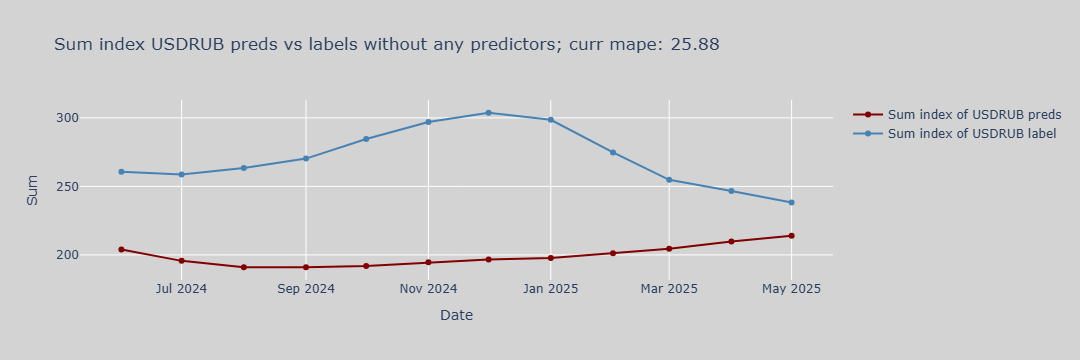

Saved forecaster to randomforest_dataset/randomforest_for_USDRUB_12.pkl and model to randomforest_dataset/randomforest_for_USDRUB_12_model.pth


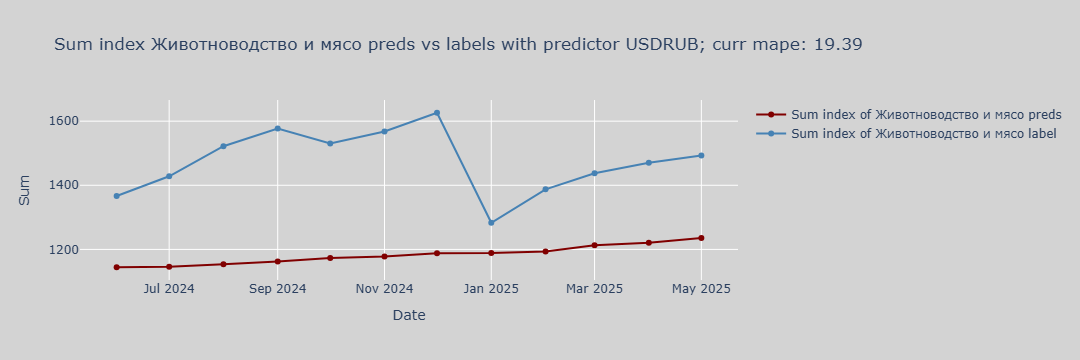

Saved forecaster to randomforest_dataset/randomforest_for_Животноводство и мясо_12.pkl and model to randomforest_dataset/randomforest_for_Животноводство и мясо_12_model.pth


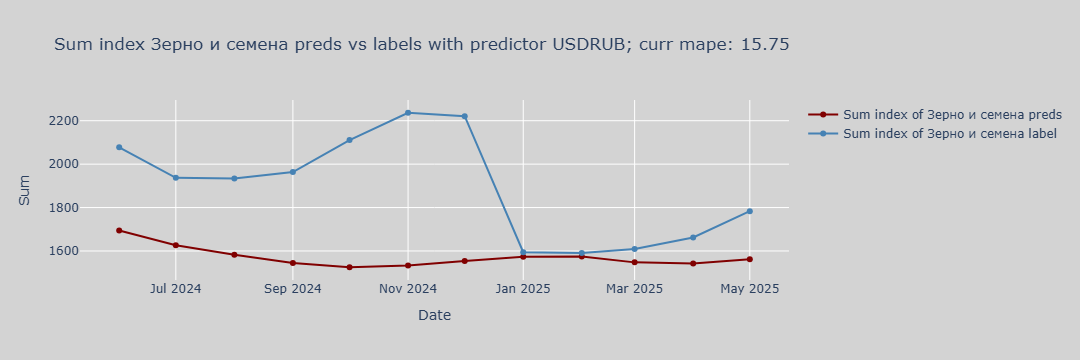

Saved forecaster to randomforest_dataset/randomforest_for_Зерно и семена_12.pkl and model to randomforest_dataset/randomforest_for_Зерно и семена_12_model.pth


ValueError: `actual_series` must be strictly positive to compute the MAPE.


Could not calculate mape for prediction due to `actual_series` must be strictly positive to compute the MAPE.


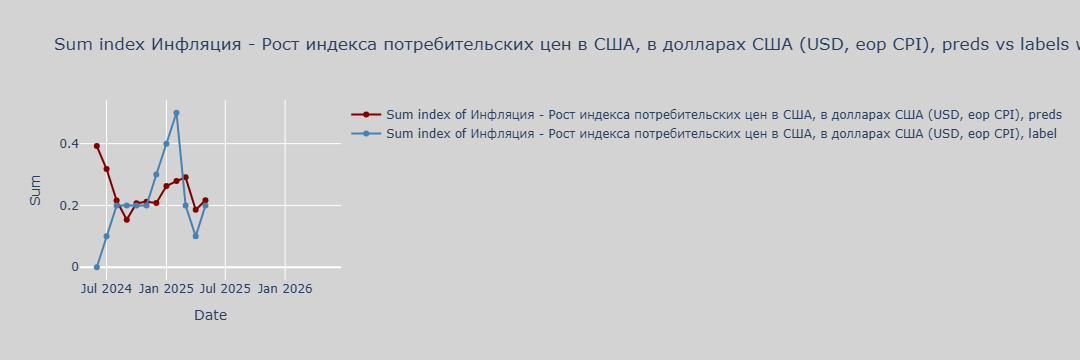

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),_12.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),_12_model.pth


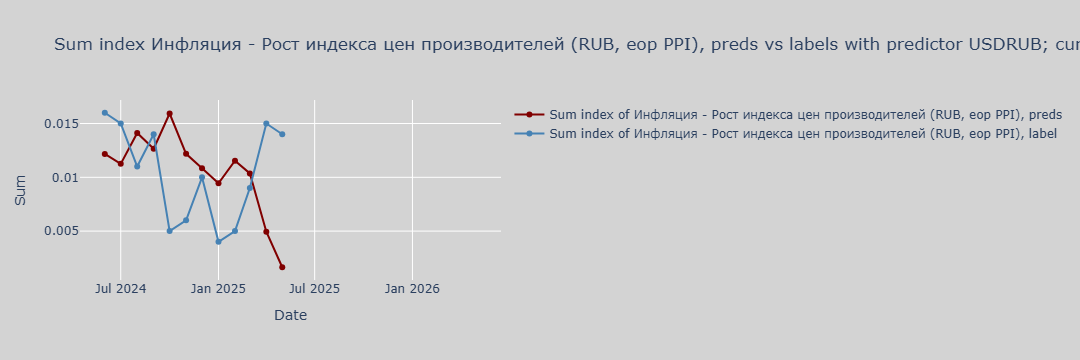

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),_12.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей (RUB, eop PPI),_12_model.pth


ValueError: `actual_series` must be strictly positive to compute the MAPE.


Could not calculate mape for prediction due to `actual_series` must be strictly positive to compute the MAPE.


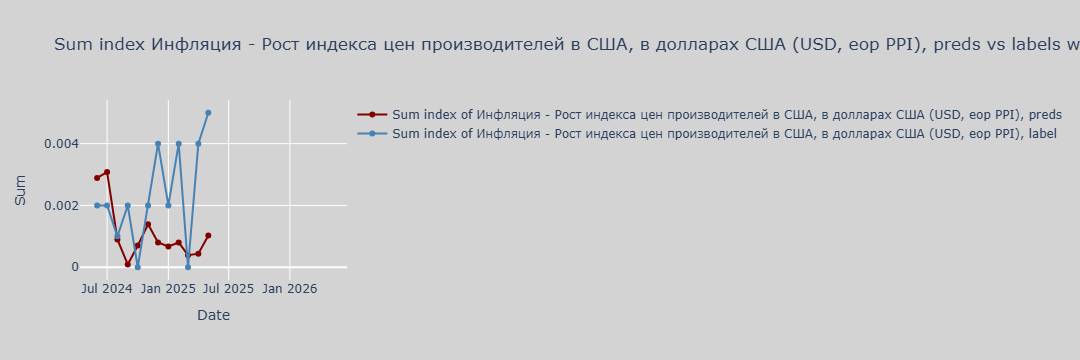

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_12.pkl and model to randomforest_dataset/randomforest_for_Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),_12_model.pth


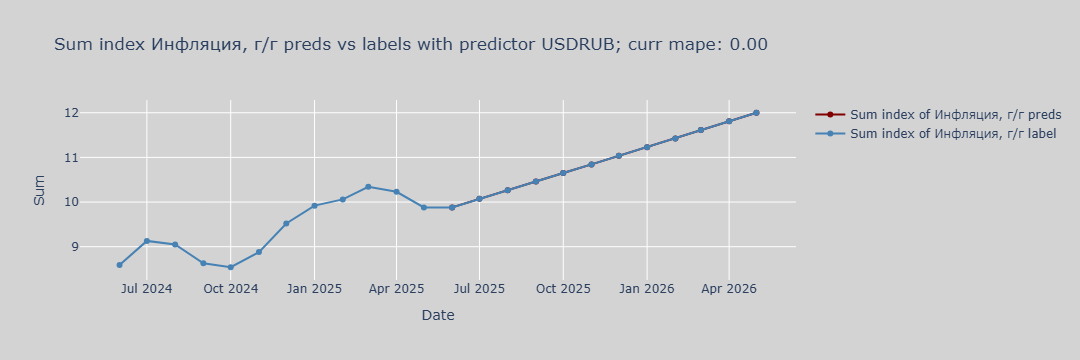

Saved forecaster to randomforest_dataset/randomforest_for_Инфляция, г_г_12.pkl and model to randomforest_dataset/randomforest_for_Инфляция, г_г_12_model.pth


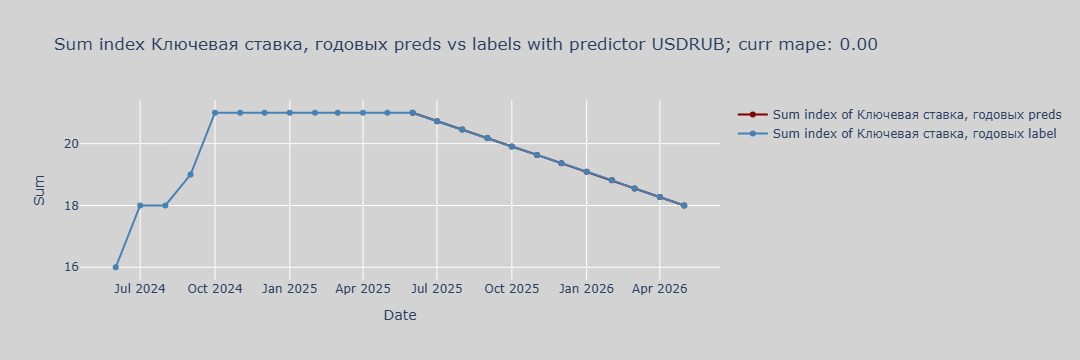

Saved forecaster to randomforest_dataset/randomforest_for_Ключевая ставка, годовых_12.pkl and model to randomforest_dataset/randomforest_for_Ключевая ставка, годовых_12_model.pth


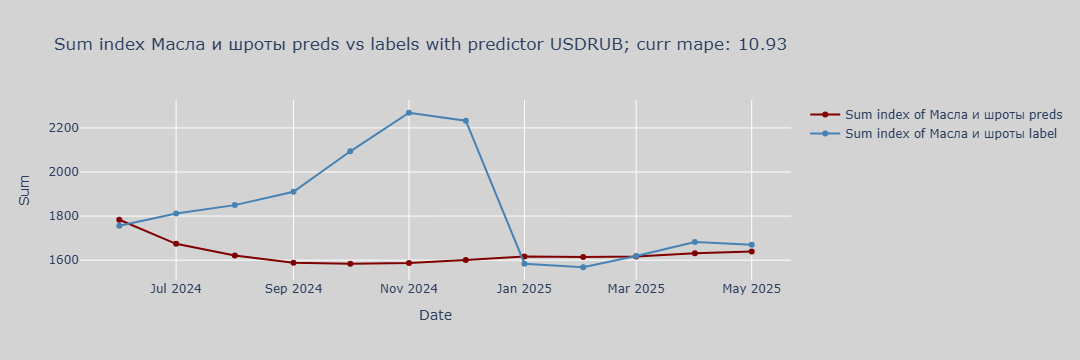

Saved forecaster to randomforest_dataset/randomforest_for_Масла и шроты_12.pkl and model to randomforest_dataset/randomforest_for_Масла и шроты_12_model.pth


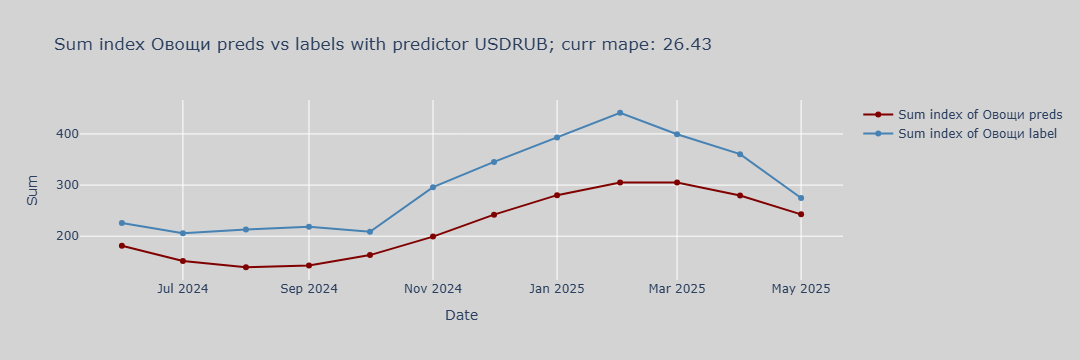

Saved forecaster to randomforest_dataset/randomforest_for_Овощи_12.pkl and model to randomforest_dataset/randomforest_for_Овощи_12_model.pth


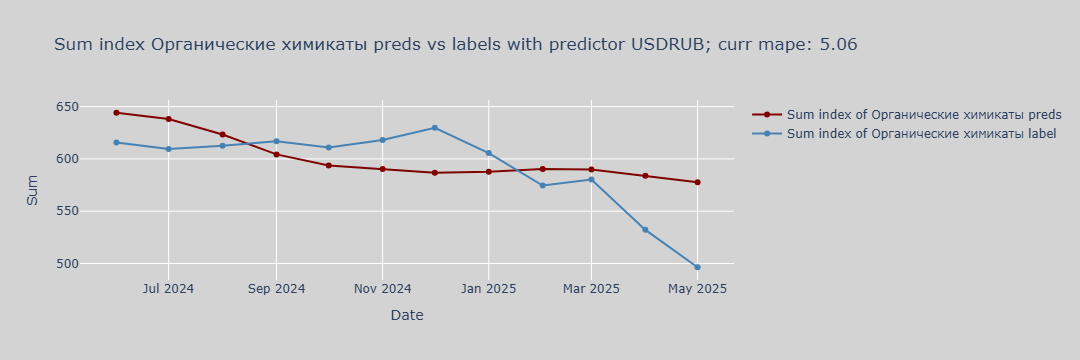

Saved forecaster to randomforest_dataset/randomforest_for_Органические химикаты_12.pkl and model to randomforest_dataset/randomforest_for_Органические химикаты_12_model.pth


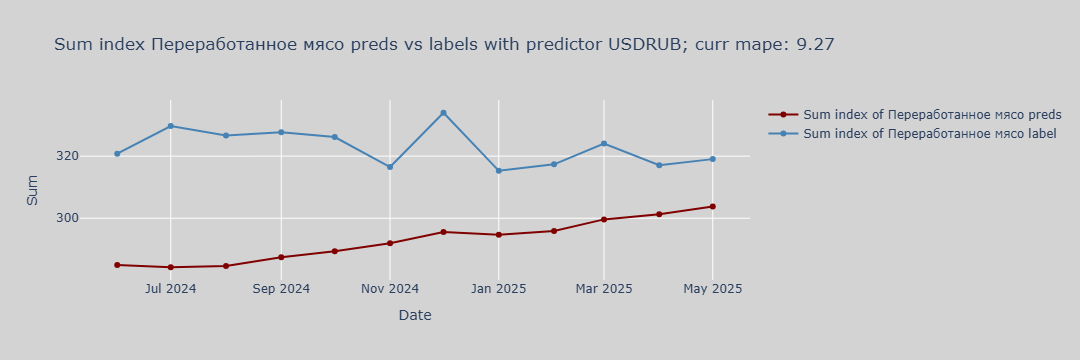

Saved forecaster to randomforest_dataset/randomforest_for_Переработанное мясо_12.pkl and model to randomforest_dataset/randomforest_for_Переработанное мясо_12_model.pth


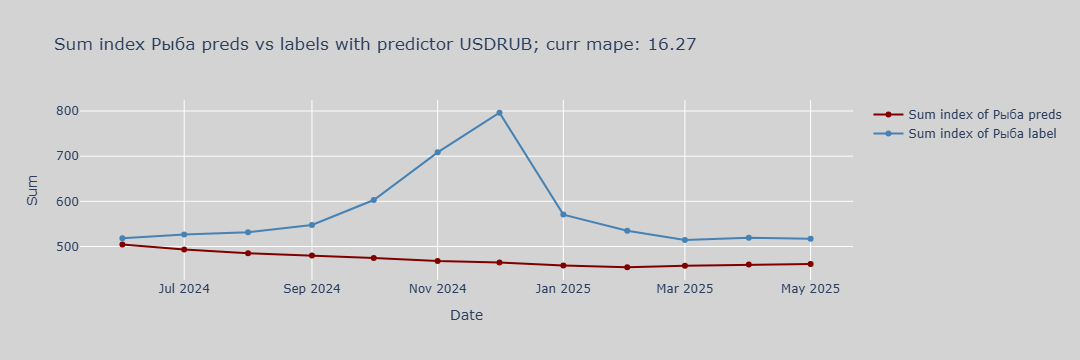

Saved forecaster to randomforest_dataset/randomforest_for_Рыба_12.pkl and model to randomforest_dataset/randomforest_for_Рыба_12_model.pth


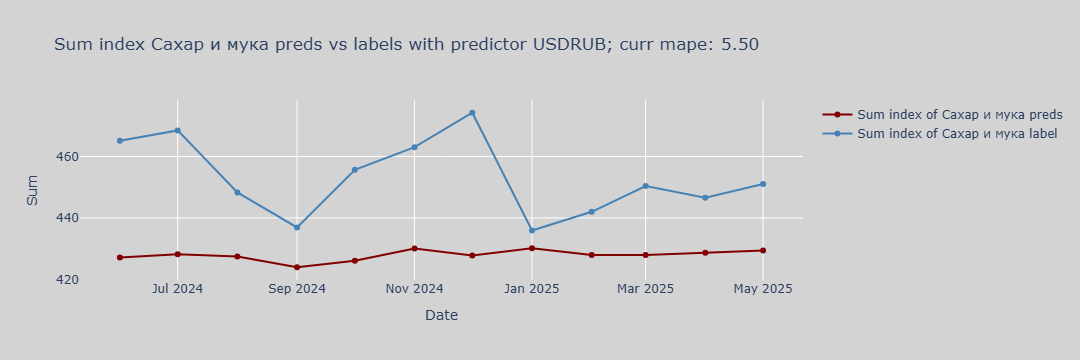

Saved forecaster to randomforest_dataset/randomforest_for_Сахар и мука_12.pkl and model to randomforest_dataset/randomforest_for_Сахар и мука_12_model.pth


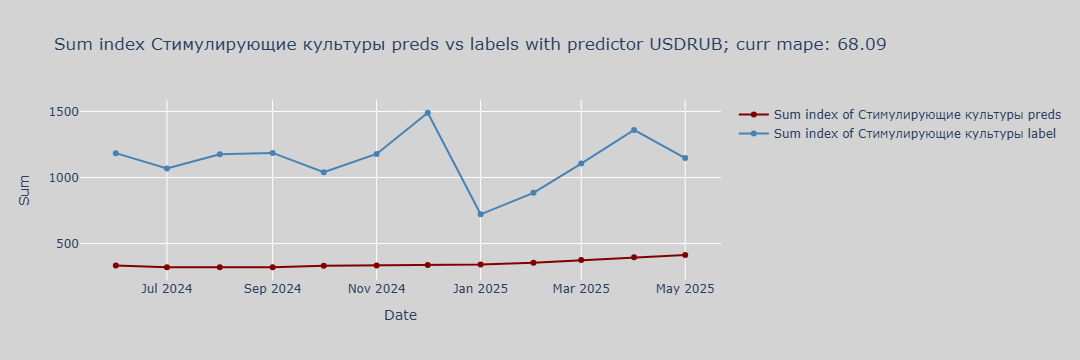

Saved forecaster to randomforest_dataset/randomforest_for_Стимулирующие культуры_12.pkl and model to randomforest_dataset/randomforest_for_Стимулирующие культуры_12_model.pth


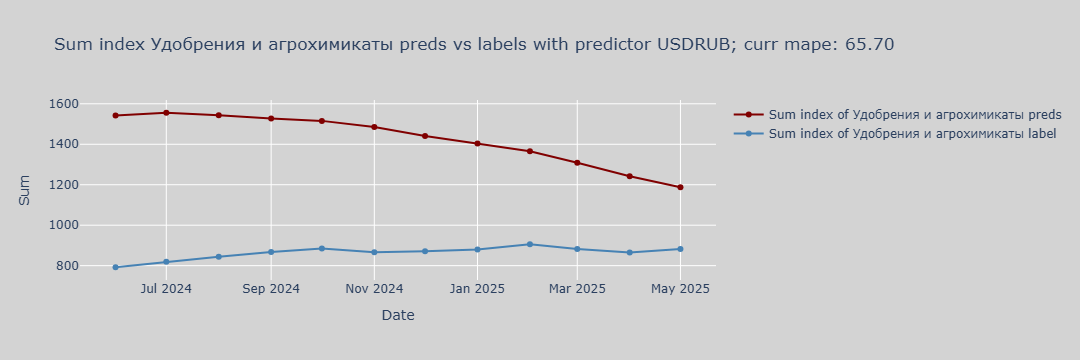

Saved forecaster to randomforest_dataset/randomforest_for_Удобрения и агрохимикаты_12.pkl and model to randomforest_dataset/randomforest_for_Удобрения и агрохимикаты_12_model.pth


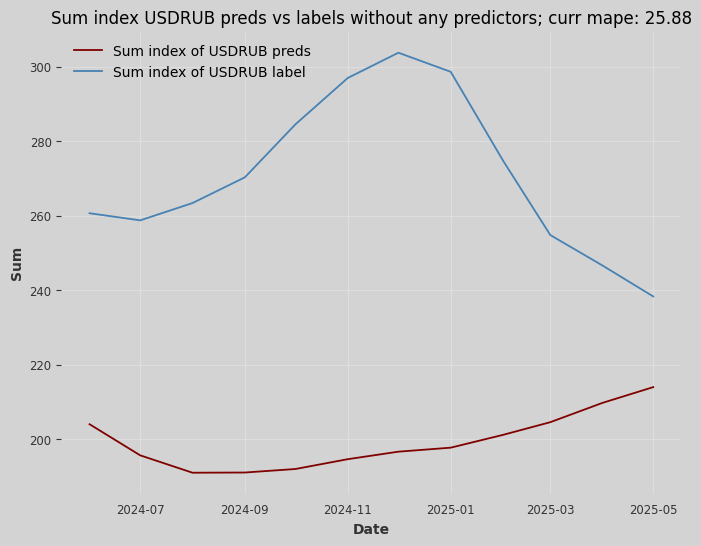

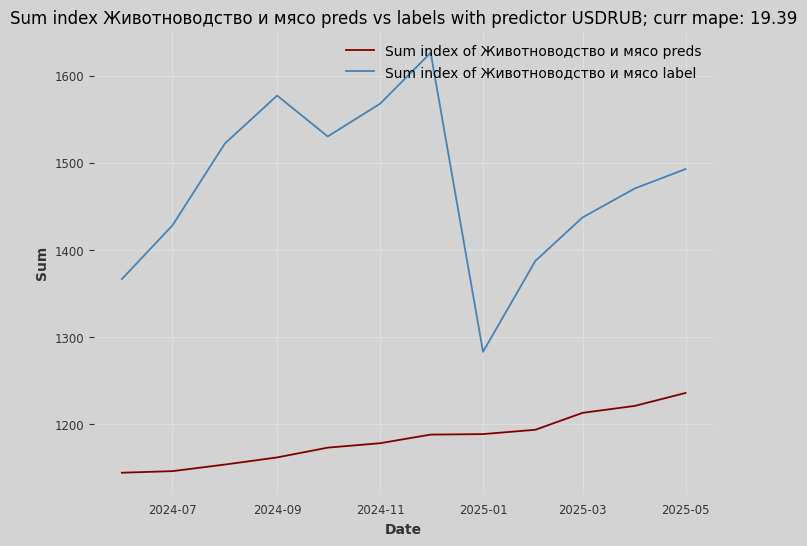

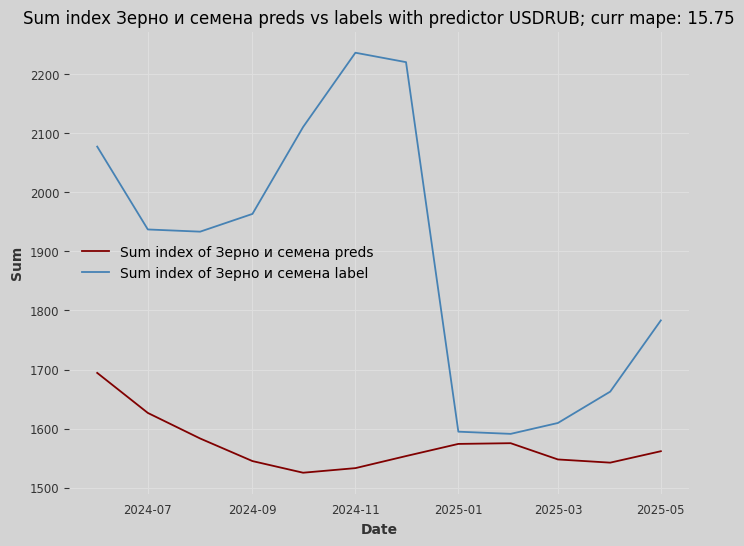

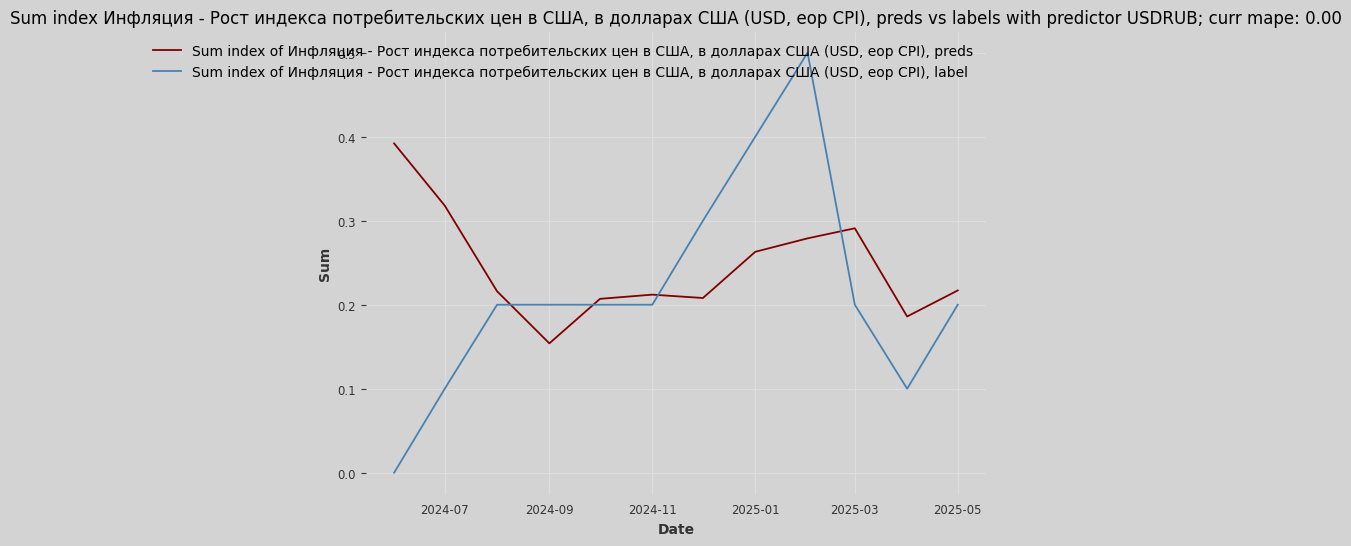

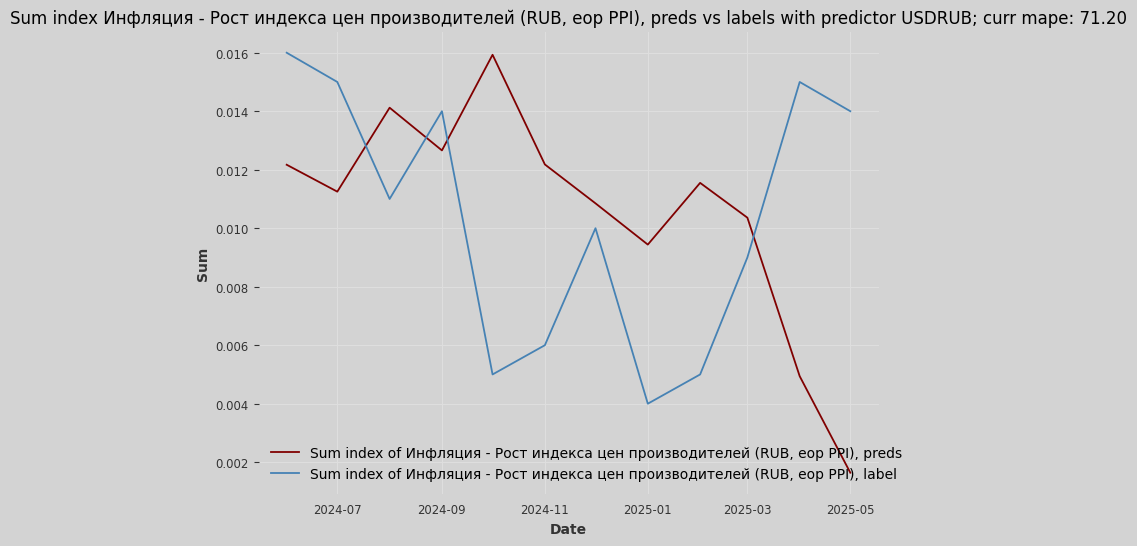

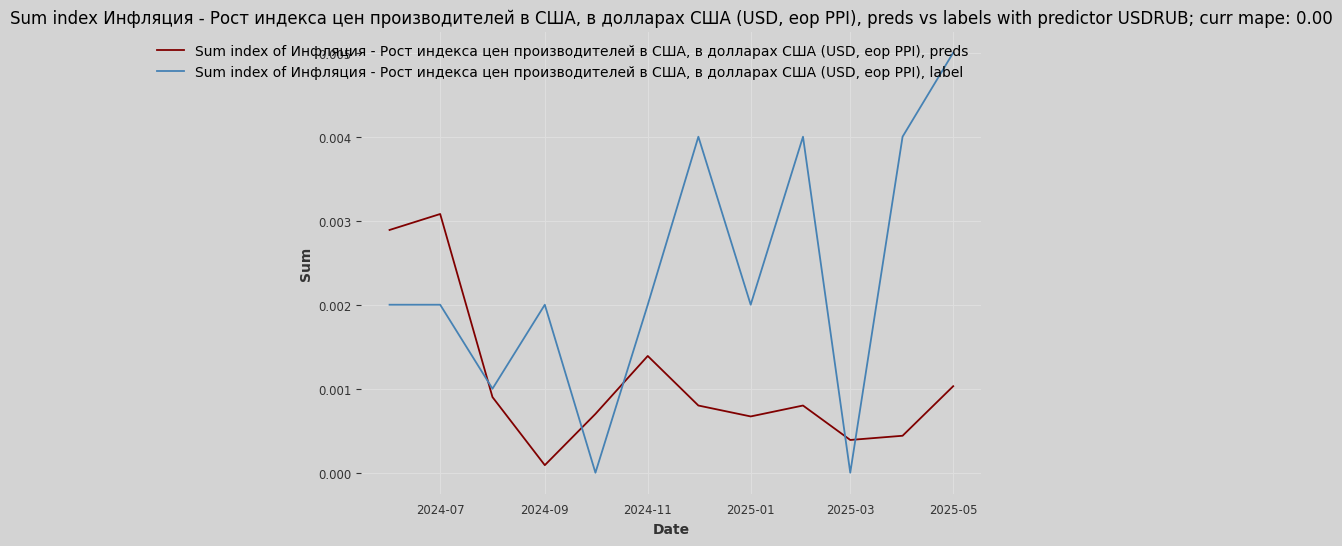

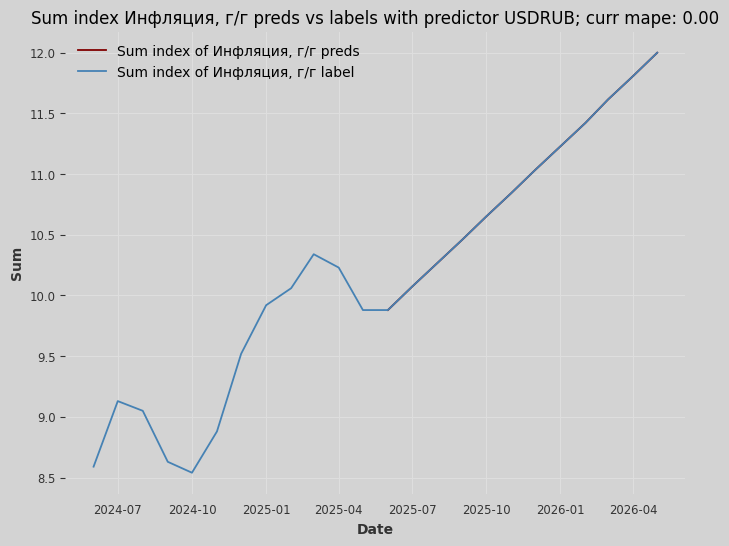

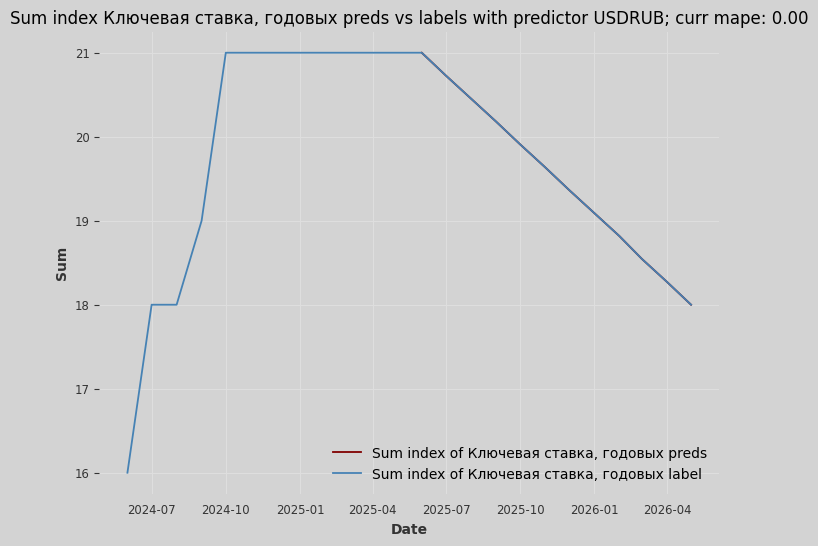

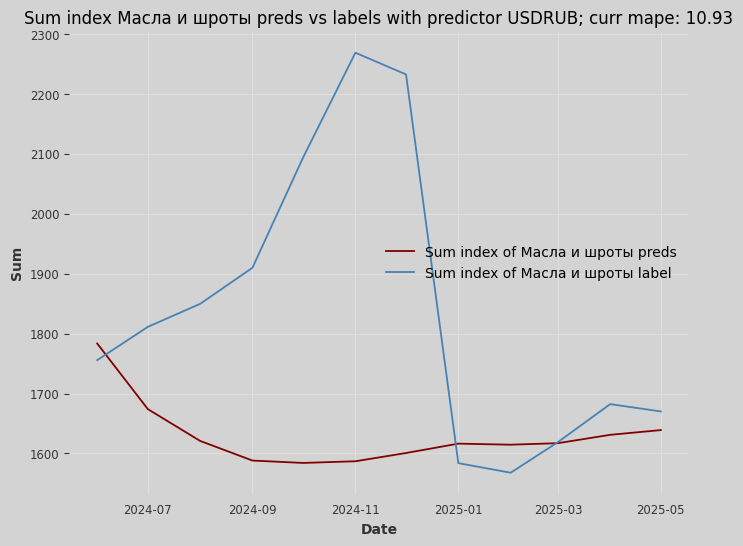

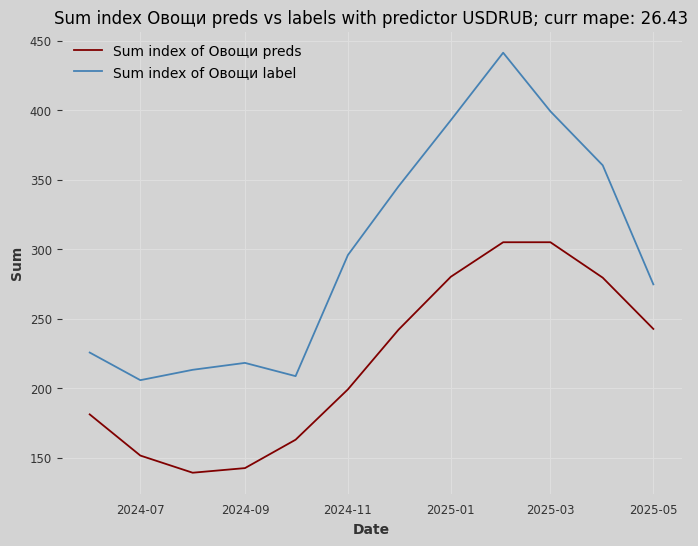

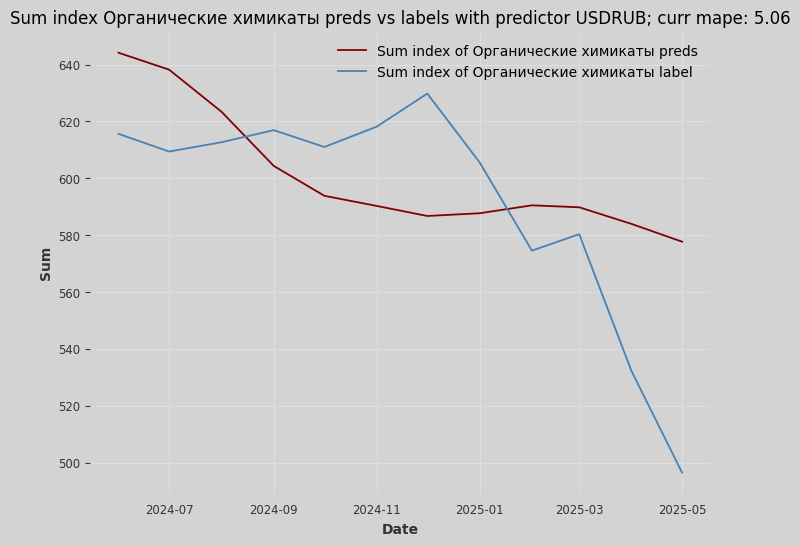

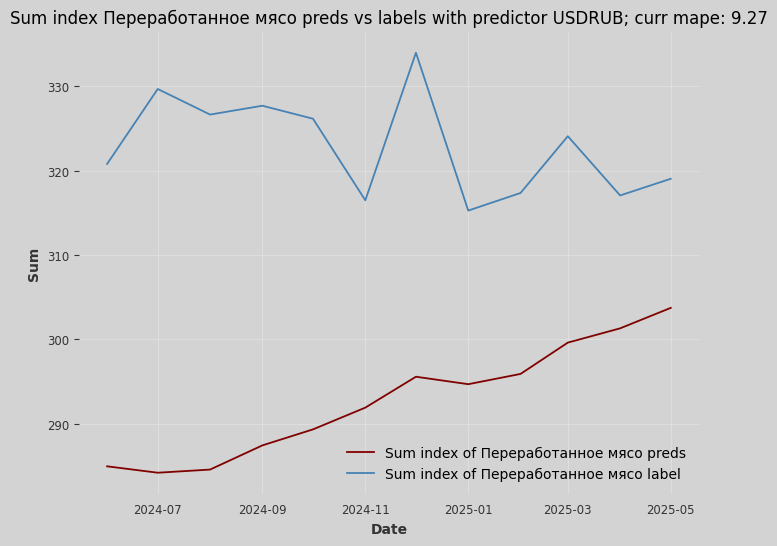

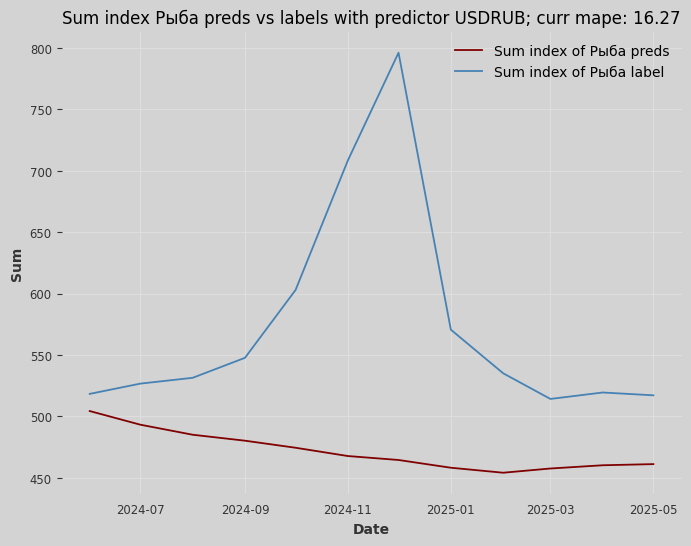

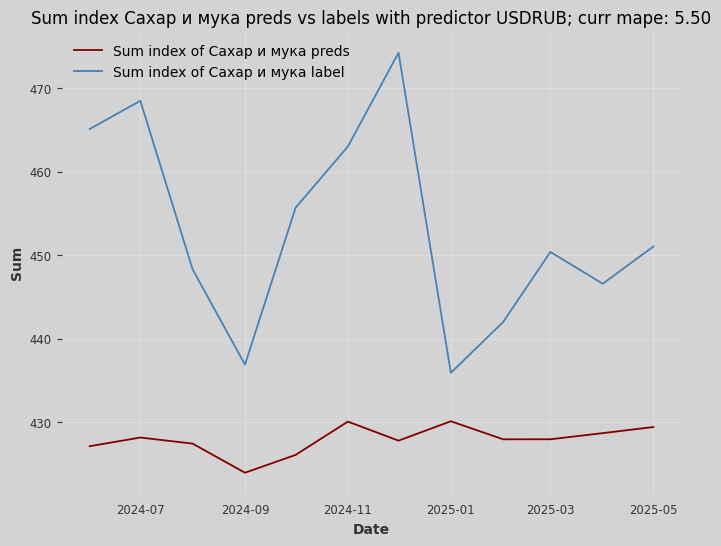

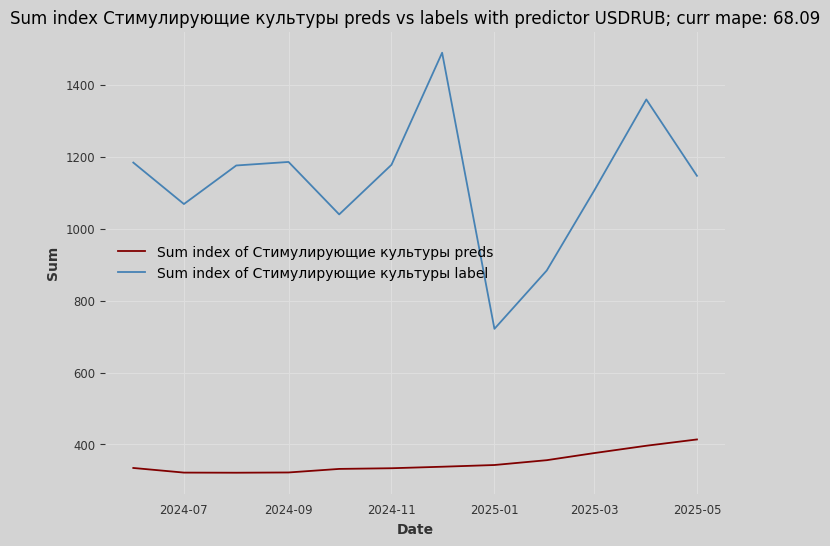

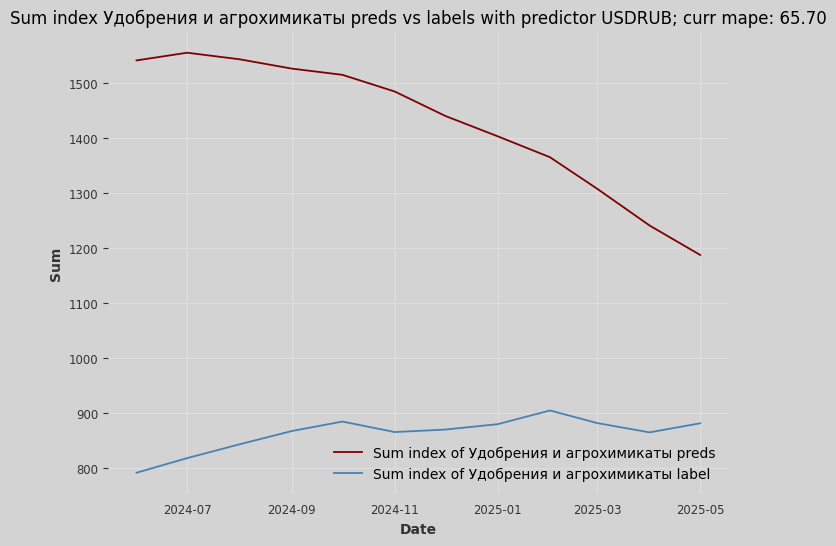

In [6]:
models = train_model_and_eval_res(df_updated,
                         macro_updated,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         predict_up_to=SINGLE_DATAPOINT_TO_PRED,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         persist_model=PERSIST_MODEL,
                         refit=REFIT_MODEL,
                         prediction_lag=PREDICTOR_LAG,
                         is_backtest=IS_BACKTEST,
                         ts_freq=TS_FREQUENCY,
                         pred_index=new_dates
)
# TODO: Научинтся конвертить в TimeSeries

---
## Inference model

In [ ]:
models = load_models(MODEL_NAME_FOR_FORECASTER, MODEL_SAVE_PATH)

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


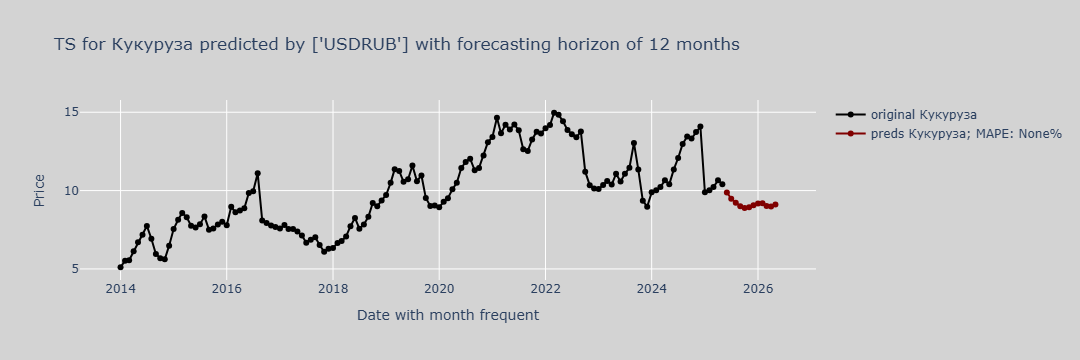

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


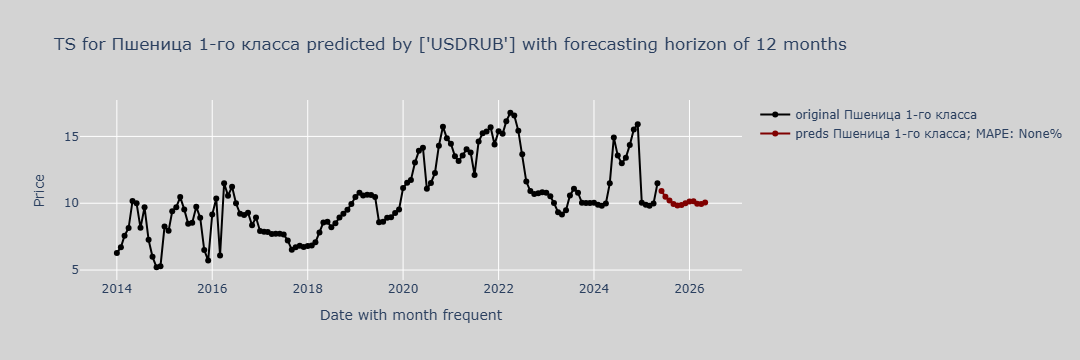

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


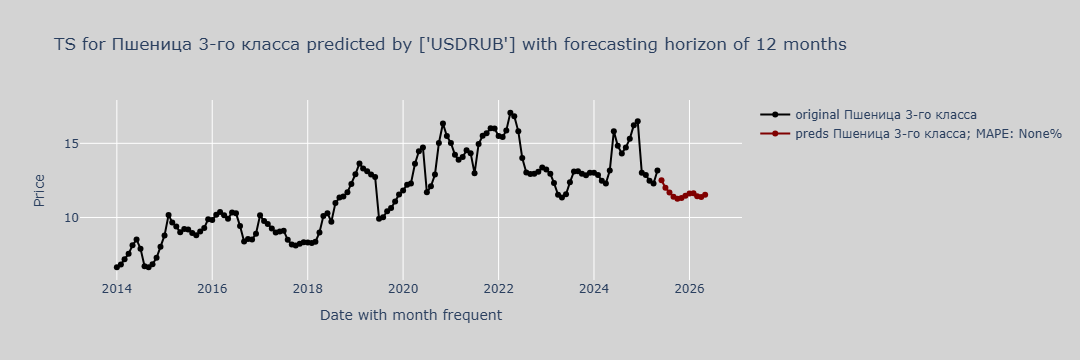

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


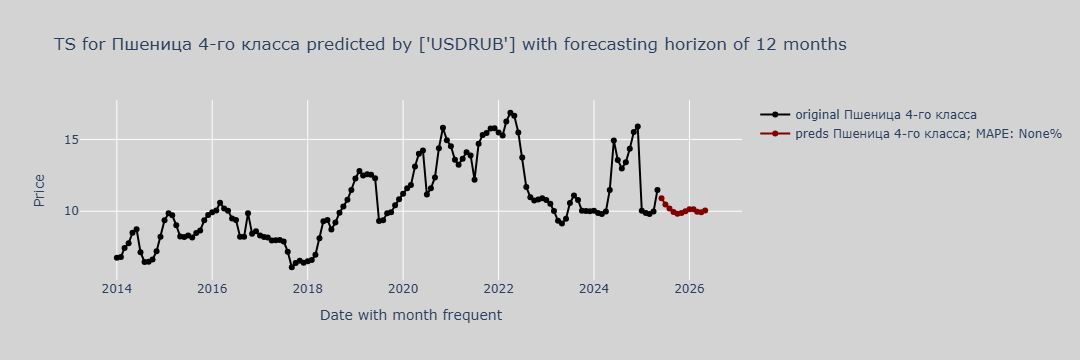

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


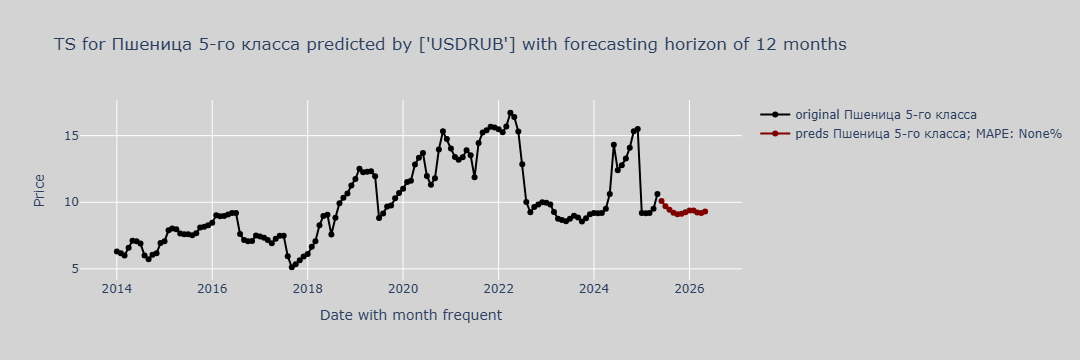

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


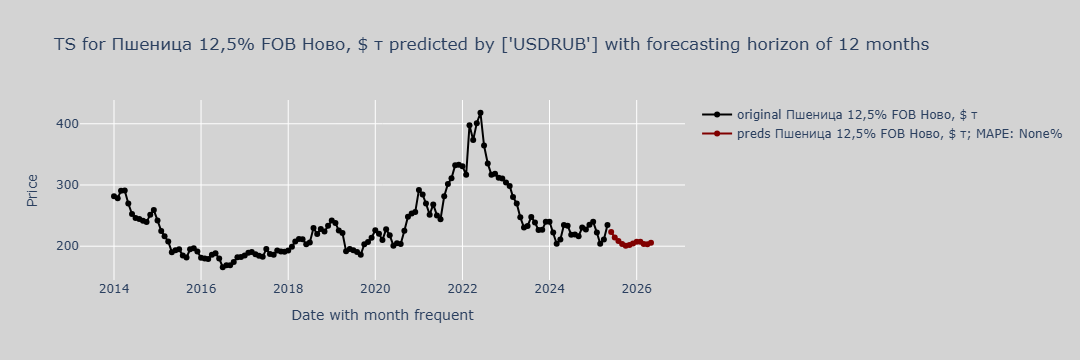

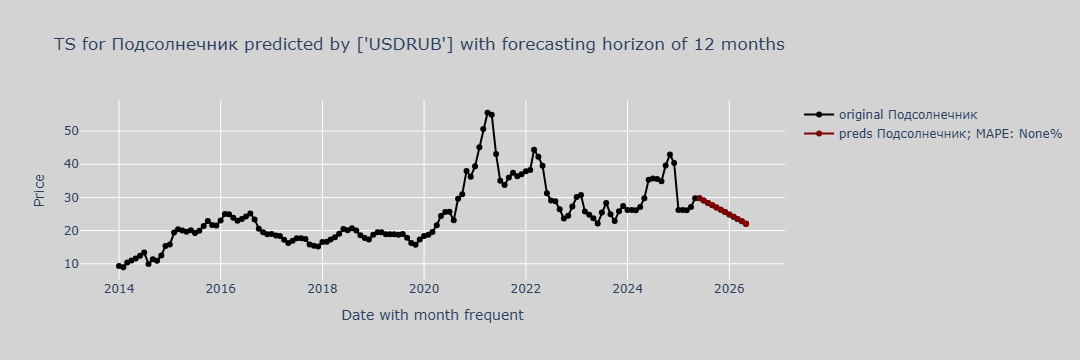

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


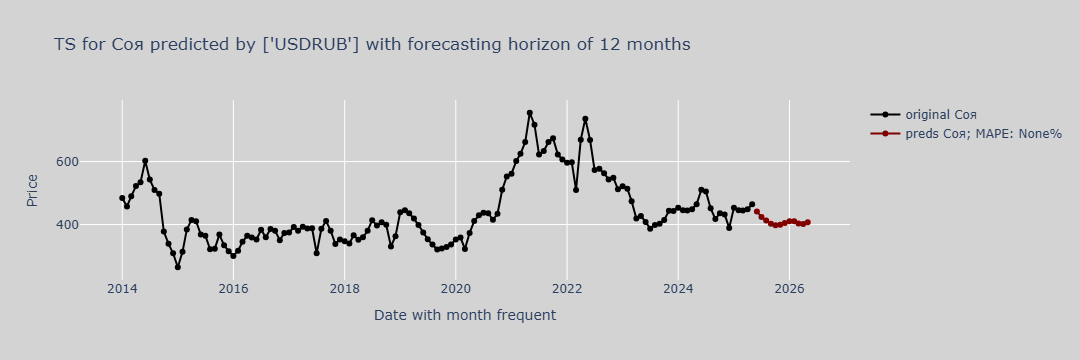

    Зерно и семена_norm_sum
0               1694.253159
1               1626.408139
2               1583.086519
3               1544.822803
4               1525.098678
5               1532.883025
6               1553.325506
7               1573.914346
8               1575.135646
9               1547.588366
10              1542.170210
11              1561.541181


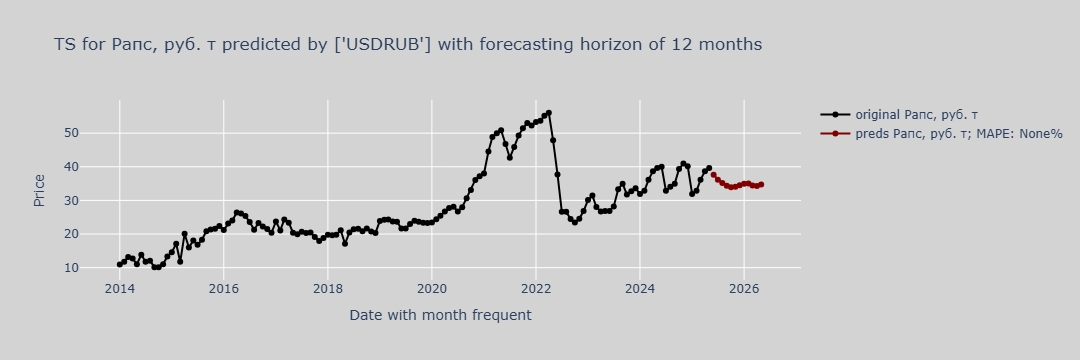

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


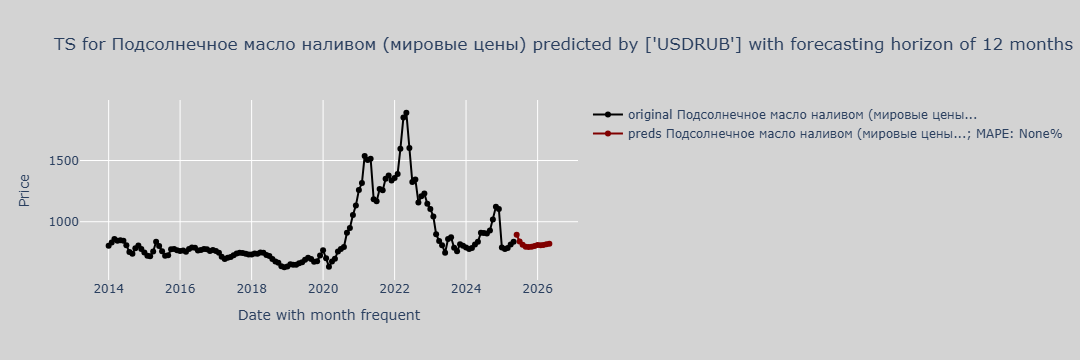

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


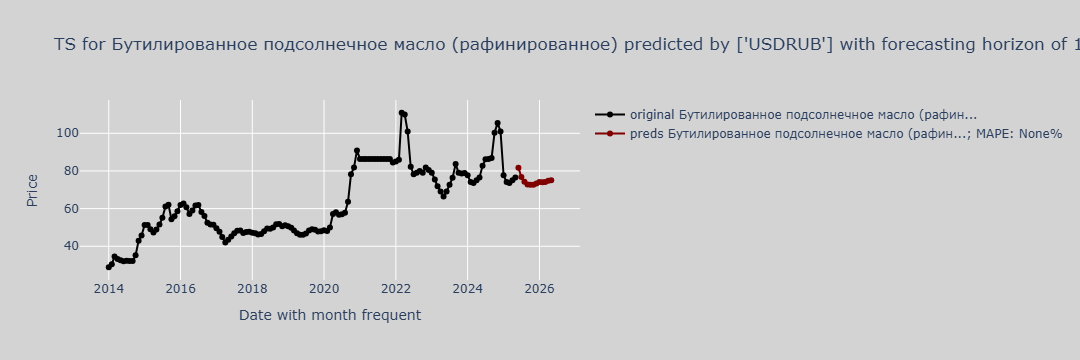

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


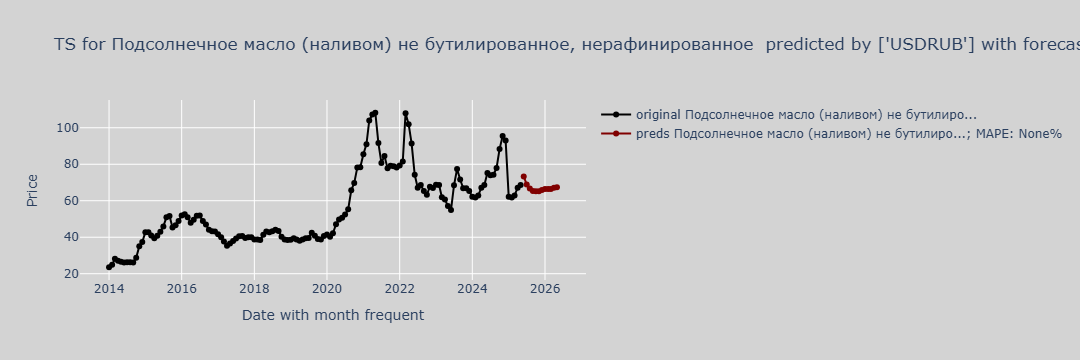

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


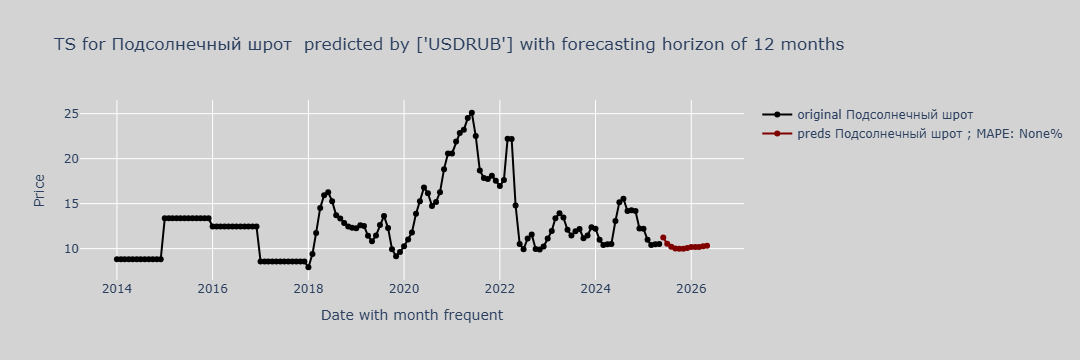

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


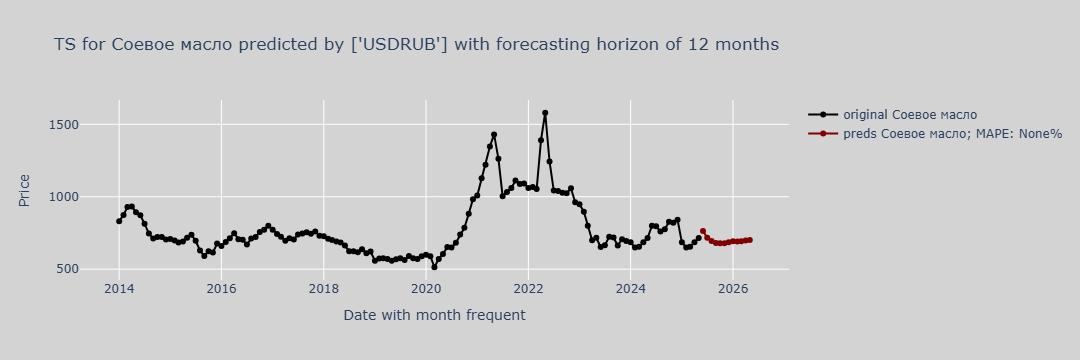

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


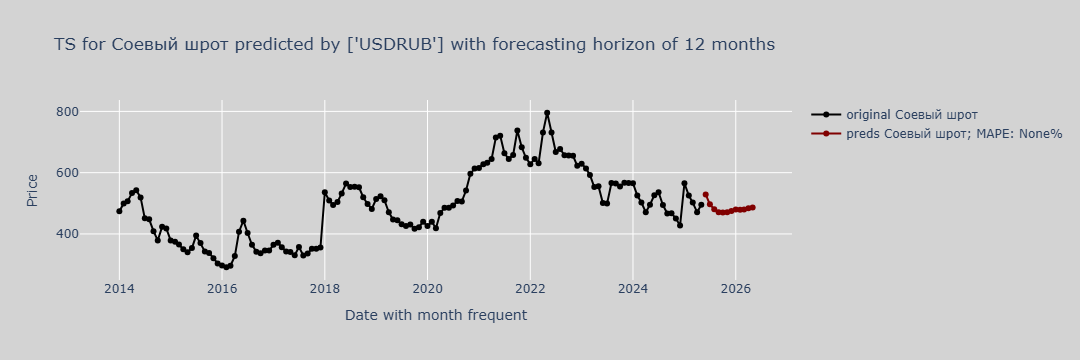

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


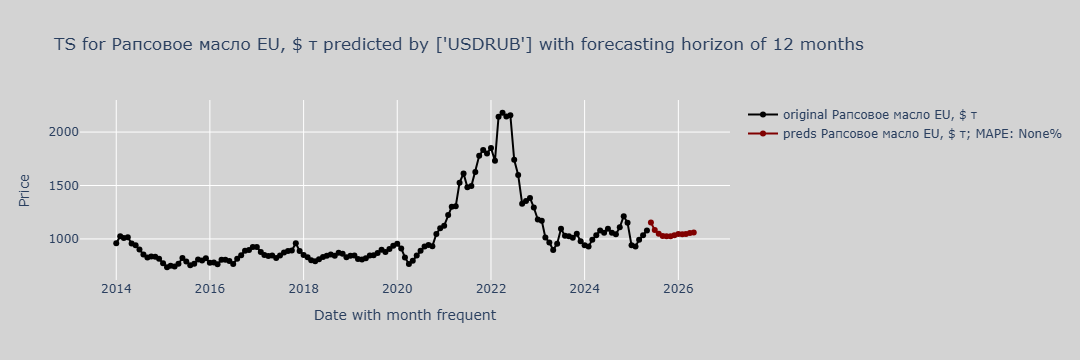

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


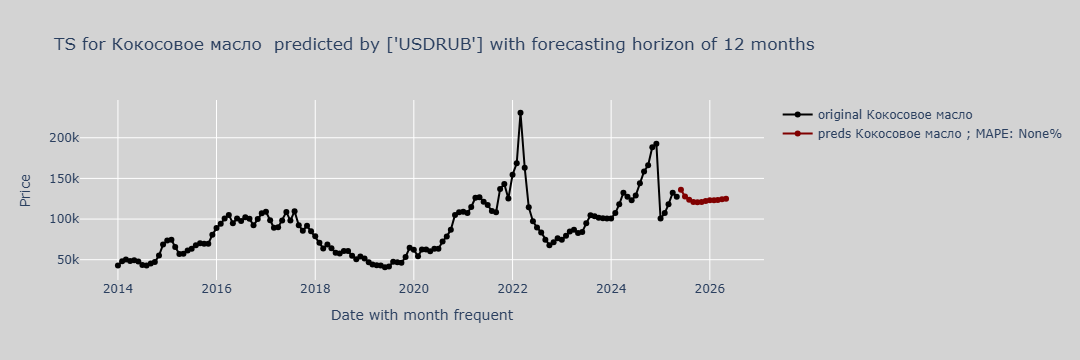

    Масла и шроты_norm_sum
0              1783.485849
1              1674.003157
2              1620.890906
3              1588.115961
4              1584.147723
5              1586.934260
6              1600.705874
7              1616.351225
8              1614.590458
9              1617.133406
10             1631.070966
11             1638.992984


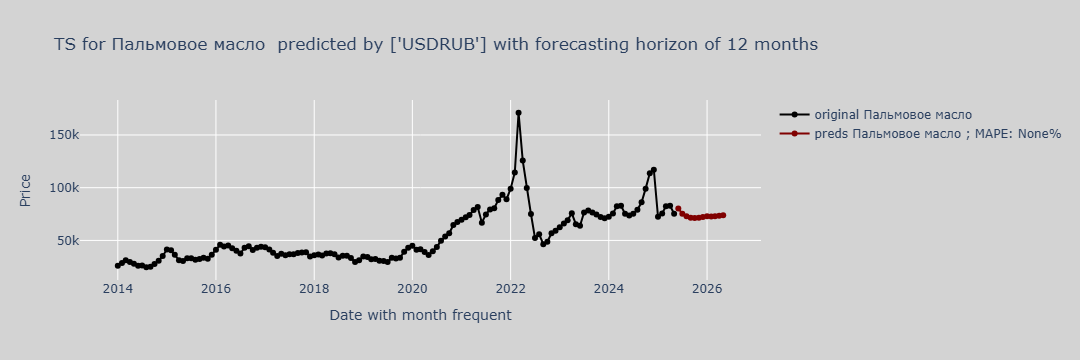

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


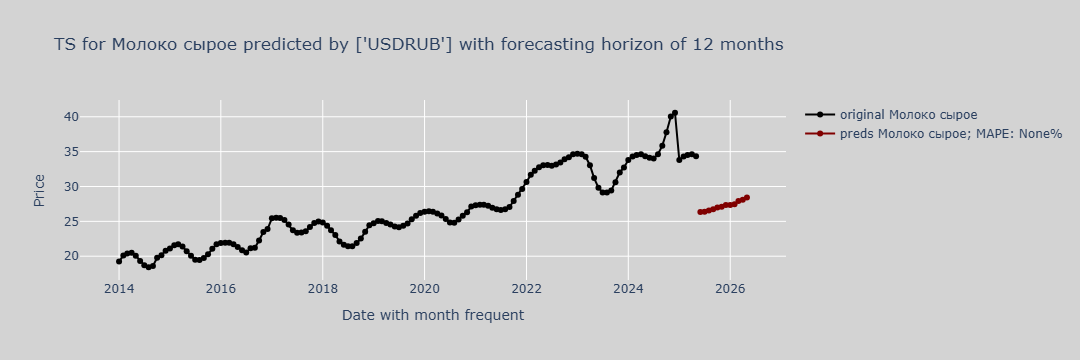

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


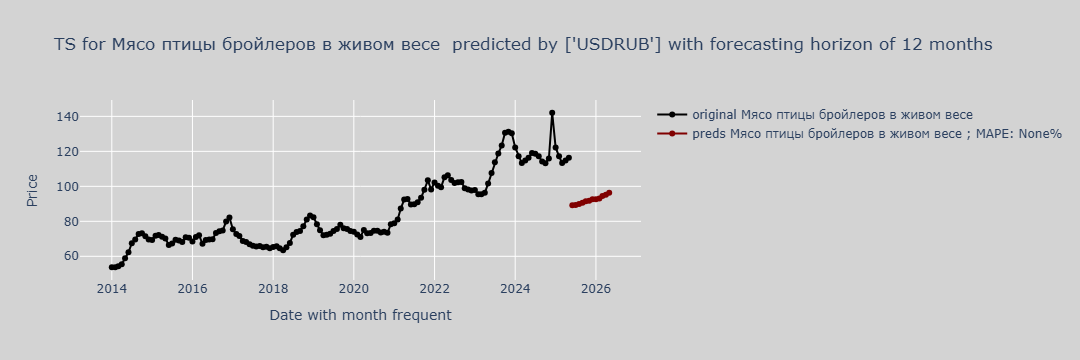

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


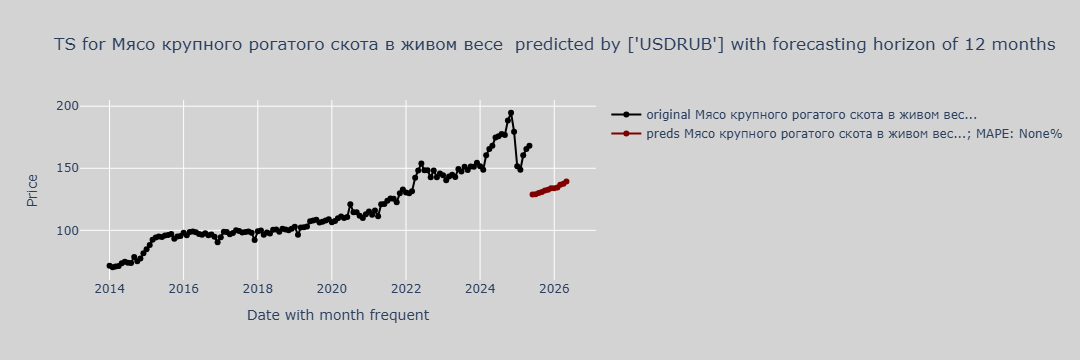

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


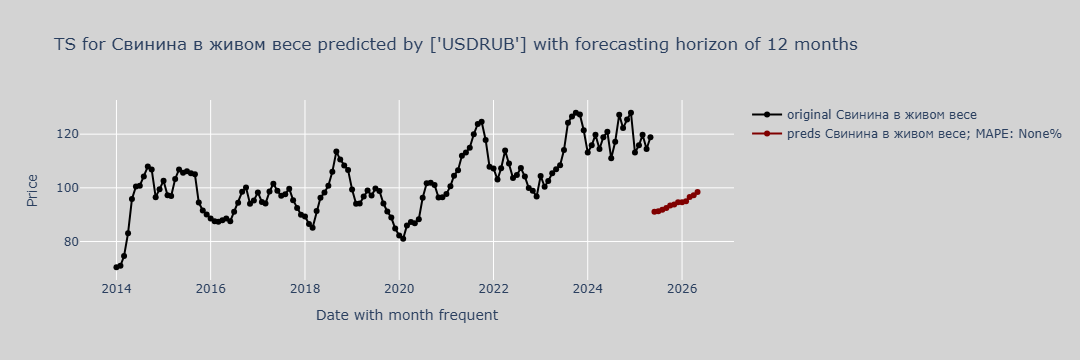

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


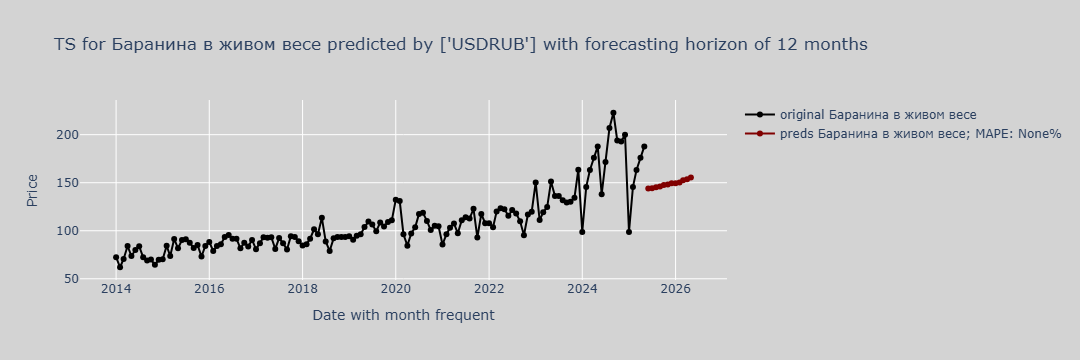

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


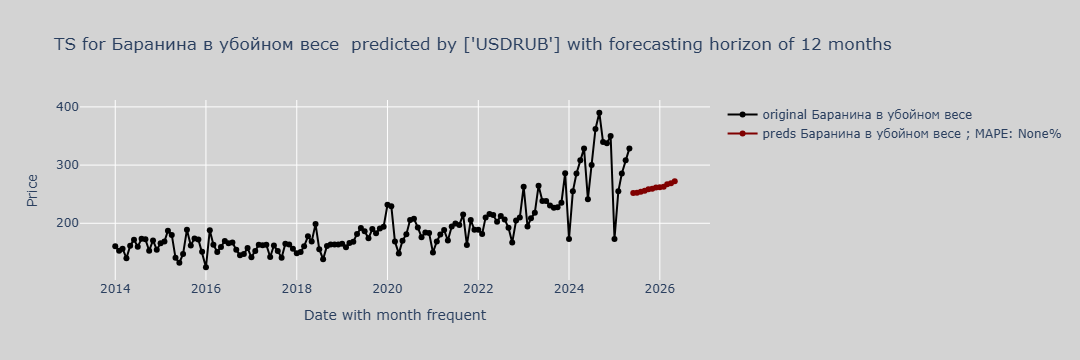

    Животноводство и мясо_norm_sum
0                      1144.353417
1                      1146.184771
2                      1153.719476
3                      1161.897240
4                      1173.132499
5                      1178.201650
6                      1188.093004
7                      1188.667758
8                      1193.623954
9                      1213.046213
10                     1221.039629
11                     1235.847335


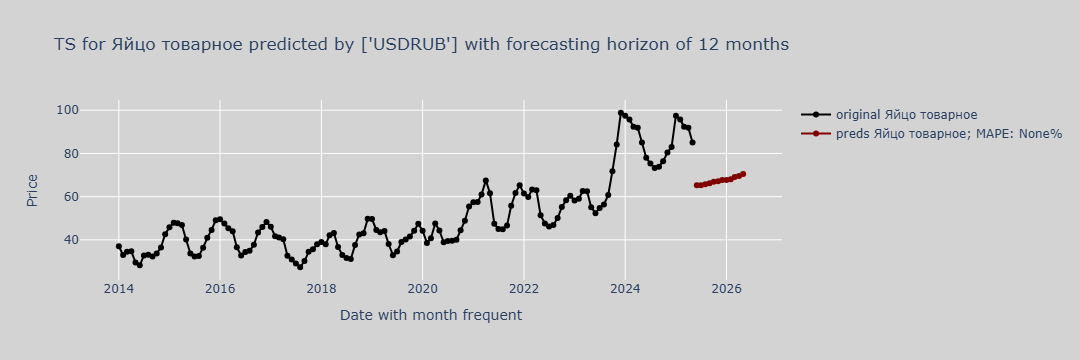

    Переработанное мясо_norm_sum
0                     284.972114
1                     284.213264
2                     284.586217
3                     287.452229
4                     289.349571
5                     291.926350
6                     295.587283
7                     294.702494
8                     295.919778
9                     299.630278
10                    301.320934
11                    303.746453


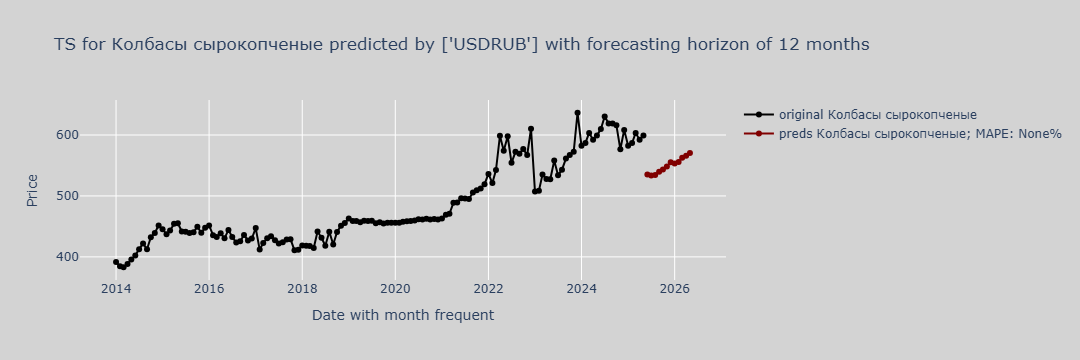

    Переработанное мясо_norm_sum
0                     284.972114
1                     284.213264
2                     284.586217
3                     287.452229
4                     289.349571
5                     291.926350
6                     295.587283
7                     294.702494
8                     295.919778
9                     299.630278
10                    301.320934
11                    303.746453


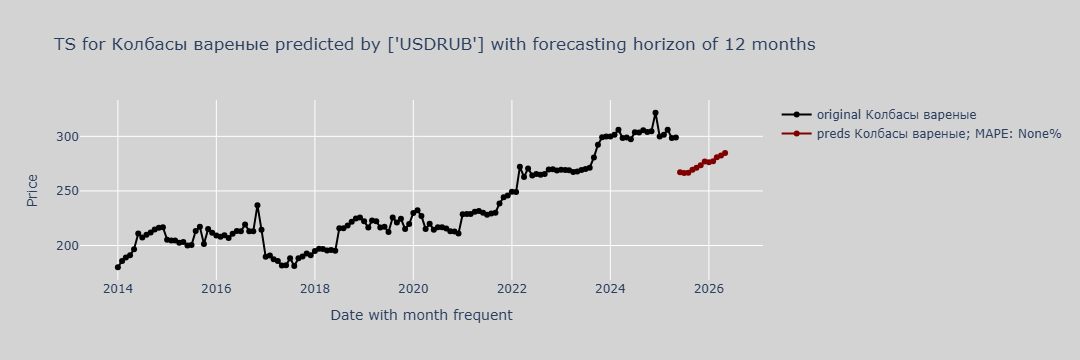

    Рыба_norm_sum
0      504.299422
1      493.177425
2      484.999854
3      480.149466
4      474.401257
5      467.647010
6      464.430834
7      458.126044
8      454.060114
9      457.496903
10     460.136857
11     461.071227


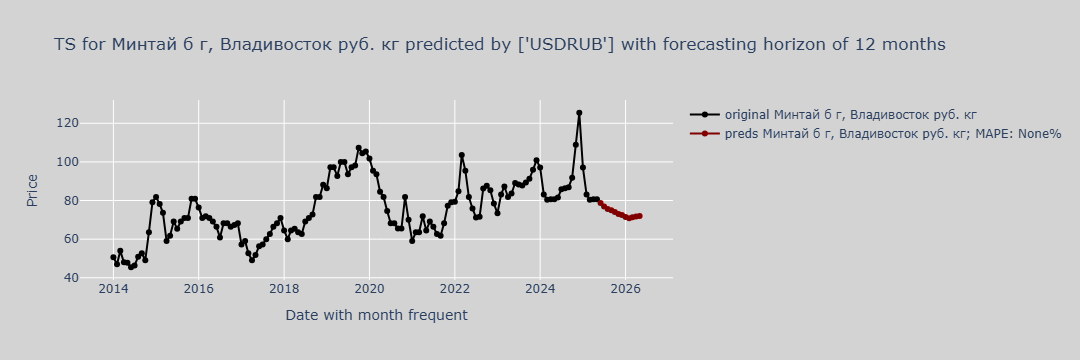

    Рыба_norm_sum
0      504.299422
1      493.177425
2      484.999854
3      480.149466
4      474.401257
5      467.647010
6      464.430834
7      458.126044
8      454.060114
9      457.496903
10     460.136857
11     461.071227


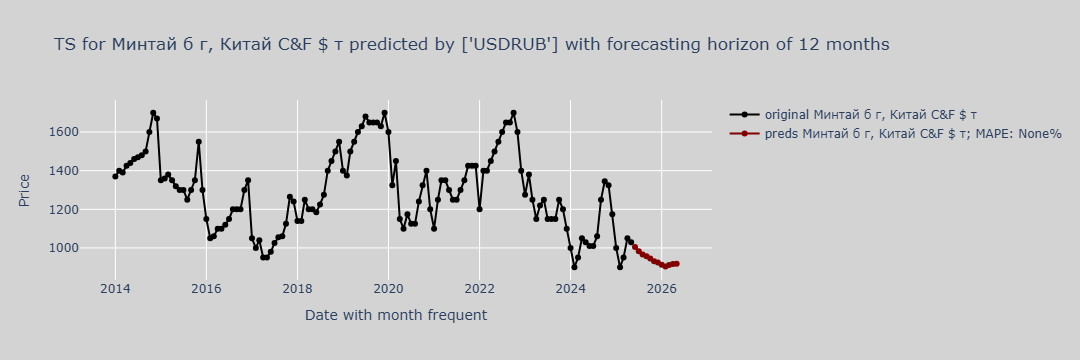

    Рыба_norm_sum
0      504.299422
1      493.177425
2      484.999854
3      480.149466
4      474.401257
5      467.647010
6      464.430834
7      458.126044
8      454.060114
9      457.496903
10     460.136857
11     461.071227


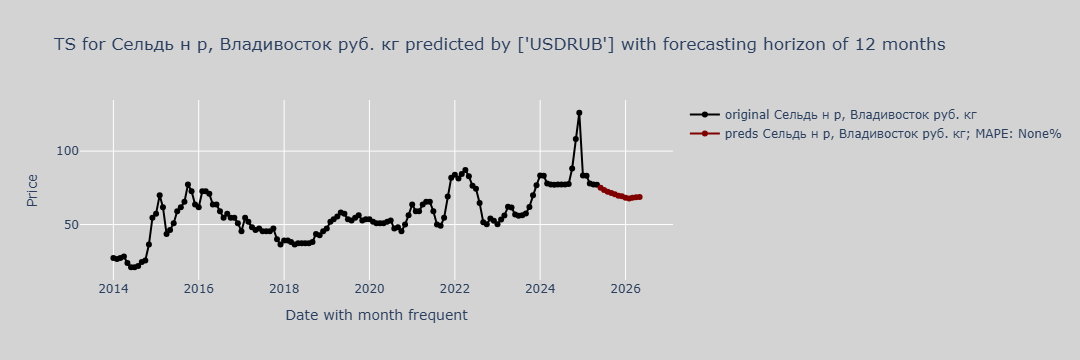

    Овощи_norm_sum
0       181.273883
1       151.649545
2       139.299406
3       142.620715
4       163.041377
5       199.267229
6       242.205395
7       280.287283
8       305.118077
9       305.126085
10      279.625338
11      242.751122


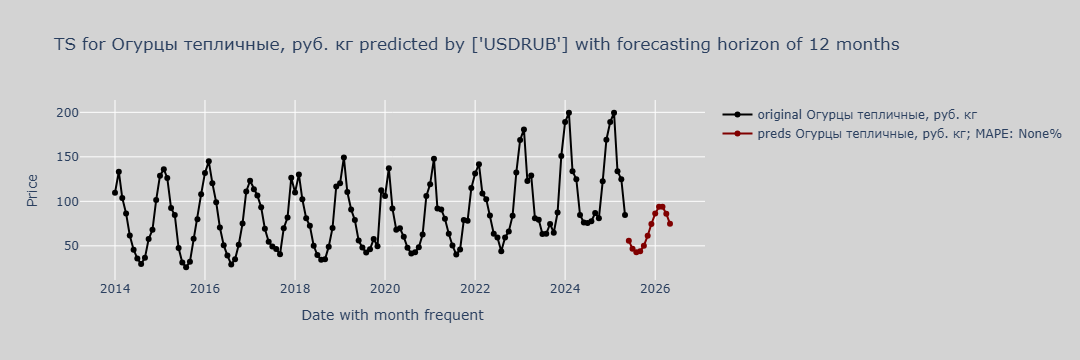

    Овощи_norm_sum
0       181.273883
1       151.649545
2       139.299406
3       142.620715
4       163.041377
5       199.267229
6       242.205395
7       280.287283
8       305.118077
9       305.126085
10      279.625338
11      242.751122


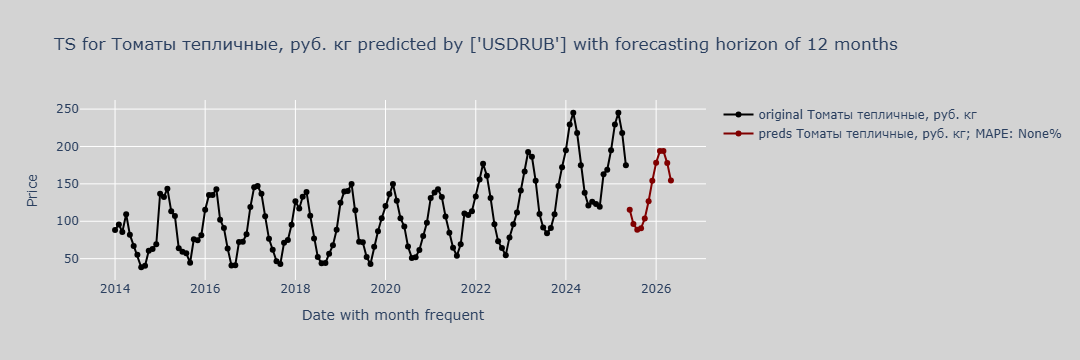

    Сахар и мука_norm_sum
0              427.146278
1              428.185955
2              427.456541
3              423.976588
4              426.107429
5              430.093642
6              427.814353
7              430.131837
8              427.974250
9              427.979061
10             428.712190
11             429.442635


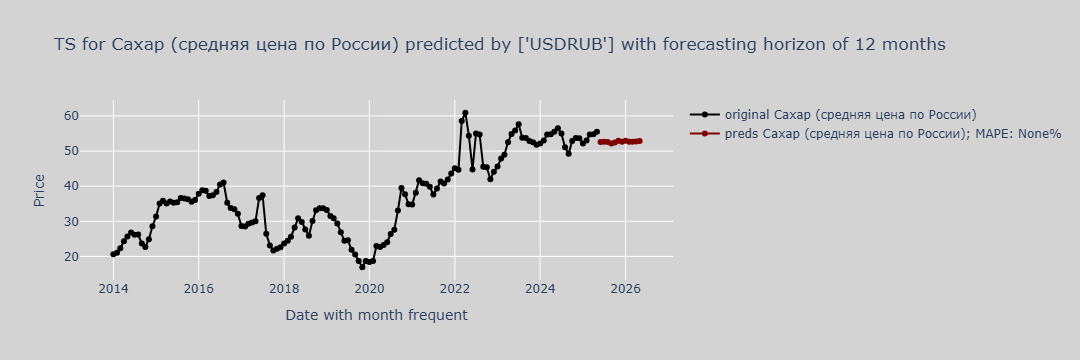

    Сахар и мука_norm_sum
0              427.146278
1              428.185955
2              427.456541
3              423.976588
4              426.107429
5              430.093642
6              427.814353
7              430.131837
8              427.974250
9              427.979061
10             428.712190
11             429.442635


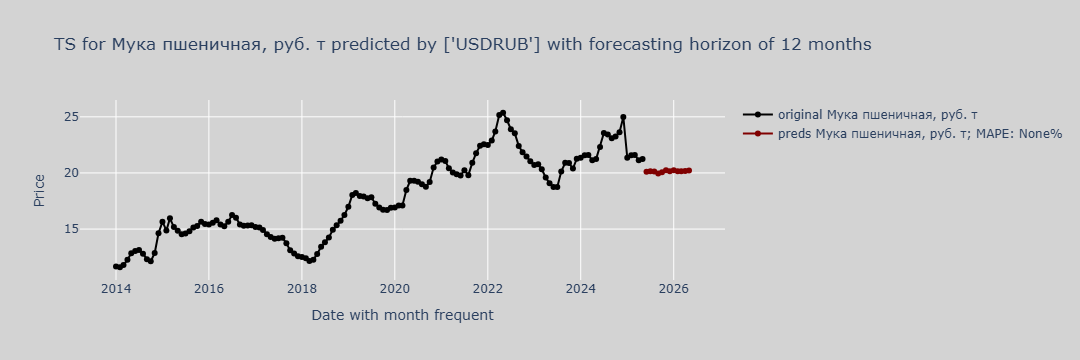

    Стимулирующие культуры_norm_sum
0                        334.612793
1                        321.722940
2                        321.390677
3                        322.097120
4                        331.982329
5                        333.858779
6                        338.040129
7                        342.835623
8                        356.255189
9                        375.936777
10                       396.410116
11                       413.925833


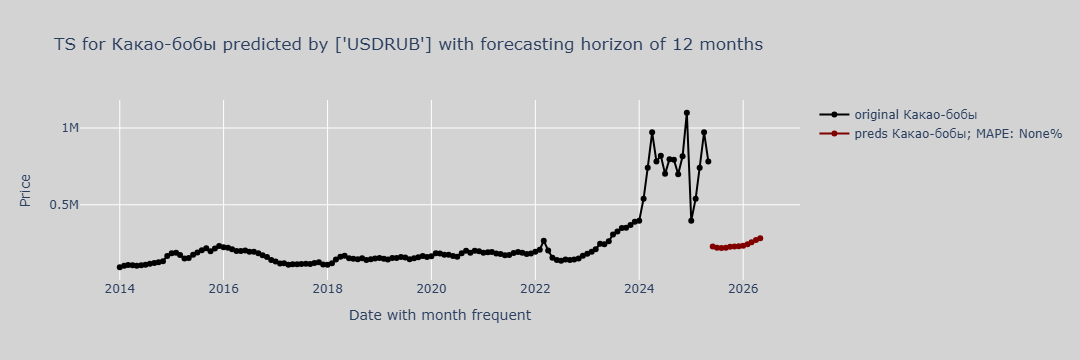

    Стимулирующие культуры_norm_sum
0                        334.612793
1                        321.722940
2                        321.390677
3                        322.097120
4                        331.982329
5                        333.858779
6                        338.040129
7                        342.835623
8                        356.255189
9                        375.936777
10                       396.410116
11                       413.925833


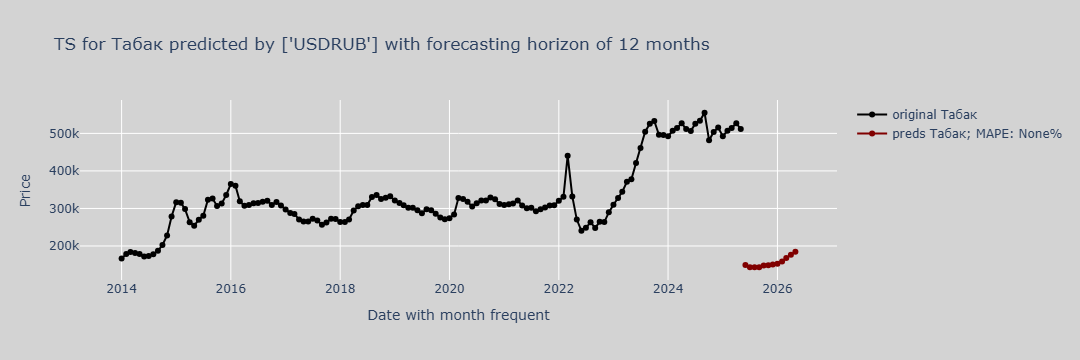

    Удобрения и агрохимикаты_norm_sum
0                         1541.861303
1                         1555.823553
2                         1543.913343
3                         1526.937153
4                         1515.632338
5                         1485.277167
6                         1440.827198
7                         1403.882691
8                         1365.811893
9                         1308.405551
10                        1241.696465
11                        1188.112342


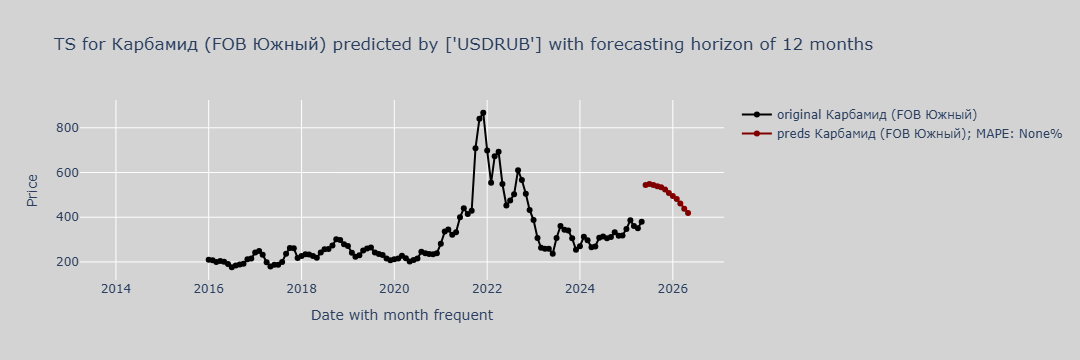

    Удобрения и агрохимикаты_norm_sum
0                         1541.861303
1                         1555.823553
2                         1543.913343
3                         1526.937153
4                         1515.632338
5                         1485.277167
6                         1440.827198
7                         1403.882691
8                         1365.811893
9                         1308.405551
10                        1241.696465
11                        1188.112342


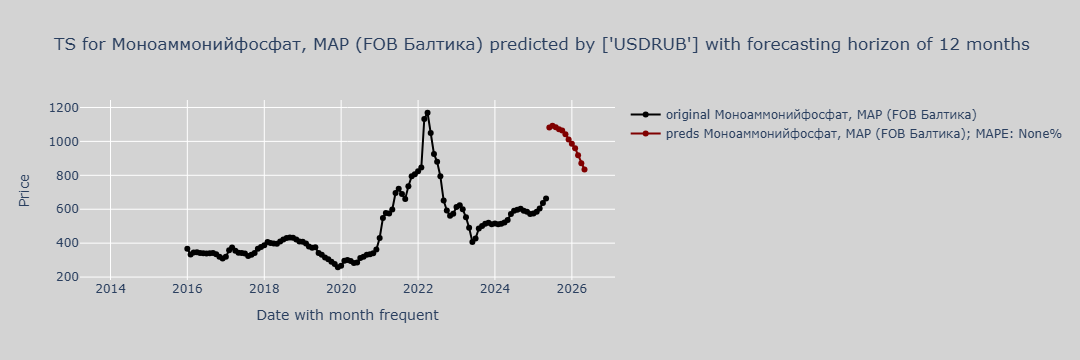

    Удобрения и агрохимикаты_norm_sum
0                         1541.861303
1                         1555.823553
2                         1543.913343
3                         1526.937153
4                         1515.632338
5                         1485.277167
6                         1440.827198
7                         1403.882691
8                         1365.811893
9                         1308.405551
10                        1241.696465
11                        1188.112342


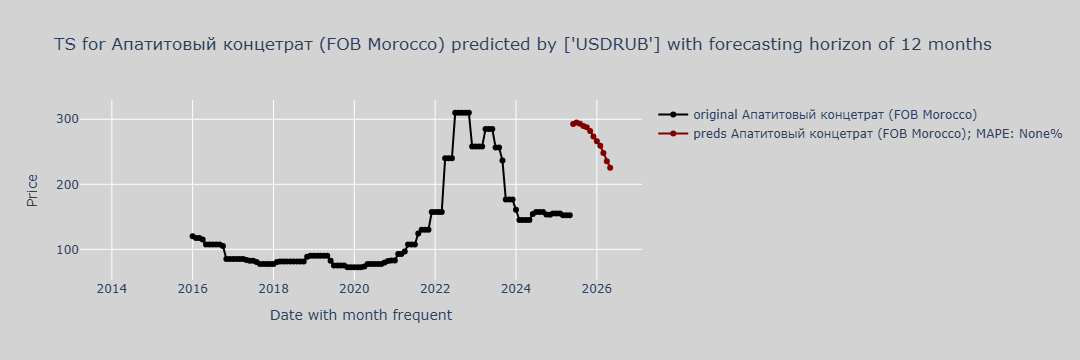

    Удобрения и агрохимикаты_norm_sum
0                         1541.861303
1                         1555.823553
2                         1543.913343
3                         1526.937153
4                         1515.632338
5                         1485.277167
6                         1440.827198
7                         1403.882691
8                         1365.811893
9                         1308.405551
10                        1241.696465
11                        1188.112342


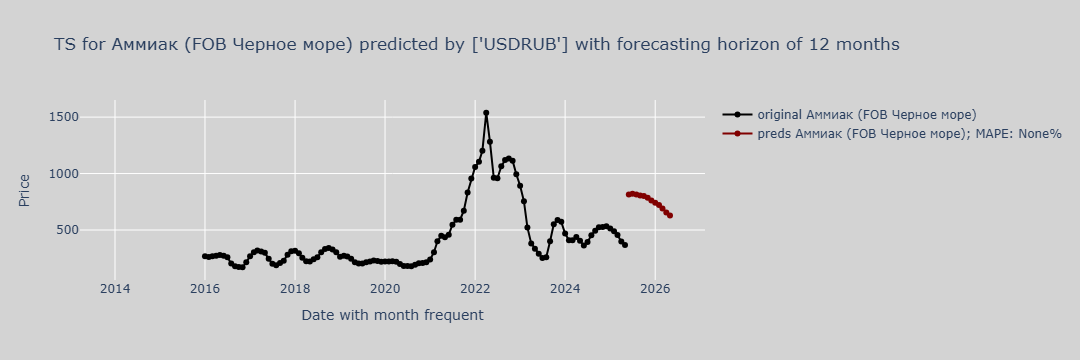

    Удобрения и агрохимикаты_norm_sum
0                         1541.861303
1                         1555.823553
2                         1543.913343
3                         1526.937153
4                         1515.632338
5                         1485.277167
6                         1440.827198
7                         1403.882691
8                         1365.811893
9                         1308.405551
10                        1241.696465
11                        1188.112342


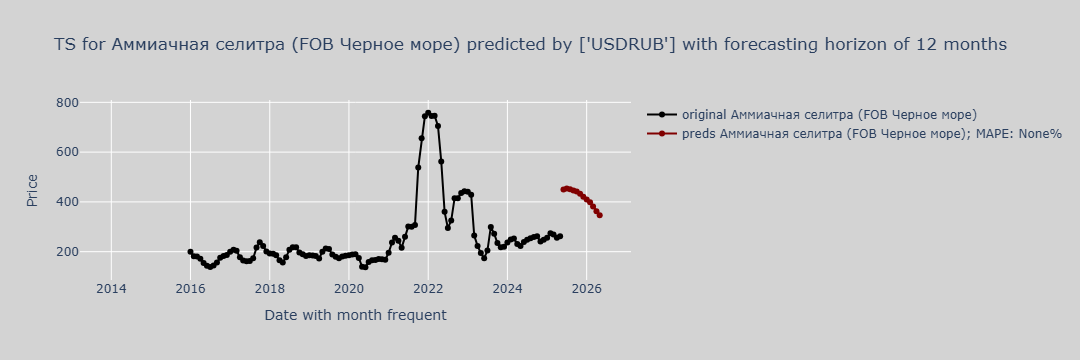

    Удобрения и агрохимикаты_norm_sum
0                         1541.861303
1                         1555.823553
2                         1543.913343
3                         1526.937153
4                         1515.632338
5                         1485.277167
6                         1440.827198
7                         1403.882691
8                         1365.811893
9                         1308.405551
10                        1241.696465
11                        1188.112342


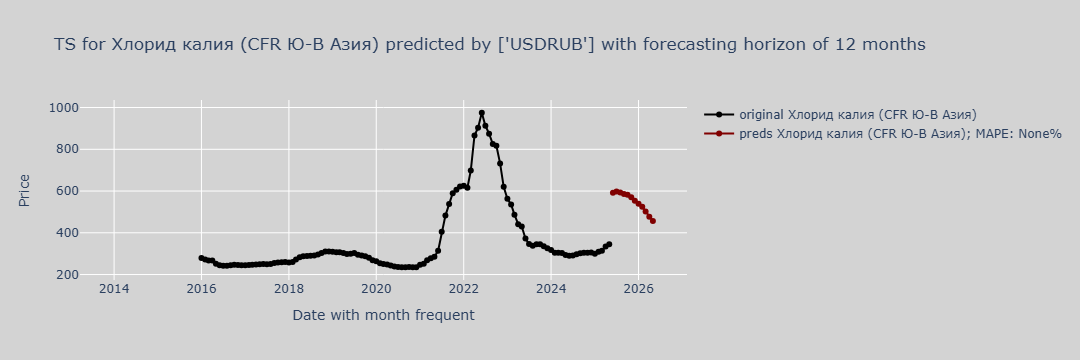

    Органические химикаты_norm_sum
0                       644.153273
1                       638.191588
2                       623.414667
3                       604.338364
4                       593.819095
5                       590.261382
6                       586.725065
7                       587.682702
8                       590.470433
9                       589.784611
10                      583.937998
11                      577.675203


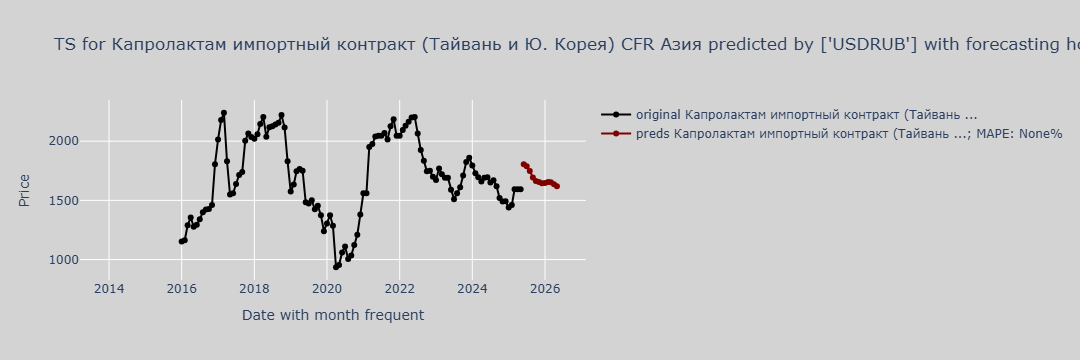

    Органические химикаты_norm_sum
0                       644.153273
1                       638.191588
2                       623.414667
3                       604.338364
4                       593.819095
5                       590.261382
6                       586.725065
7                       587.682702
8                       590.470433
9                       589.784611
10                      583.937998
11                      577.675203


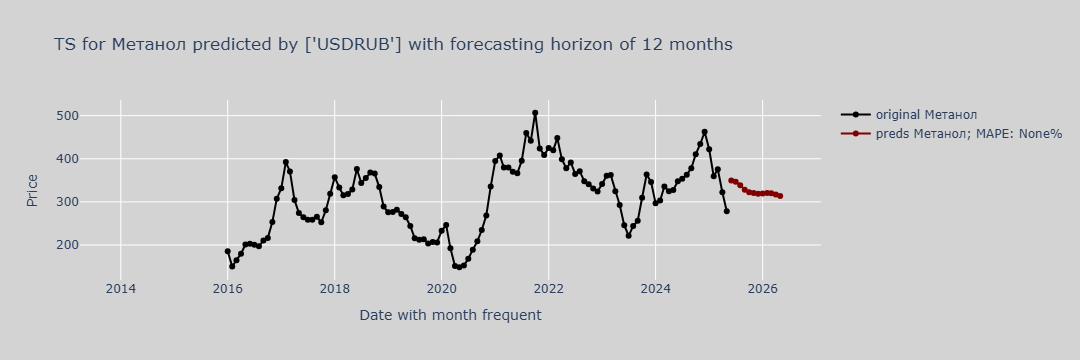

    Органические химикаты_norm_sum
0                       644.153273
1                       638.191588
2                       623.414667
3                       604.338364
4                       593.819095
5                       590.261382
6                       586.725065
7                       587.682702
8                       590.470433
9                       589.784611
10                      583.937998
11                      577.675203


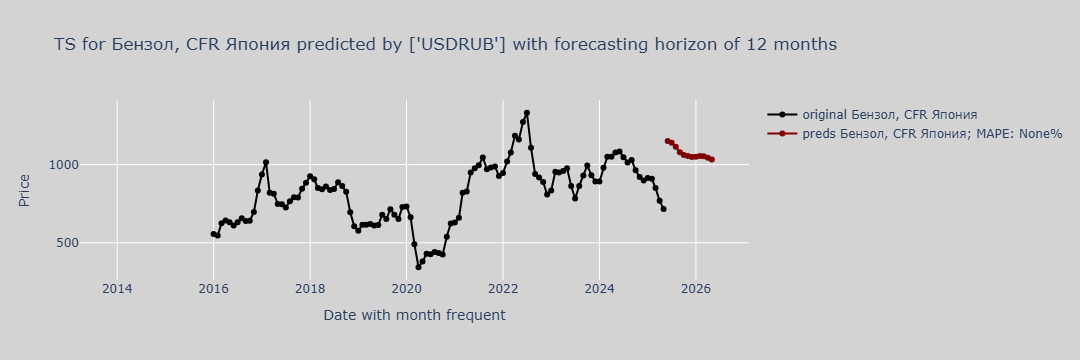

    Органические химикаты_norm_sum
0                       644.153273
1                       638.191588
2                       623.414667
3                       604.338364
4                       593.819095
5                       590.261382
6                       586.725065
7                       587.682702
8                       590.470433
9                       589.784611
10                      583.937998
11                      577.675203


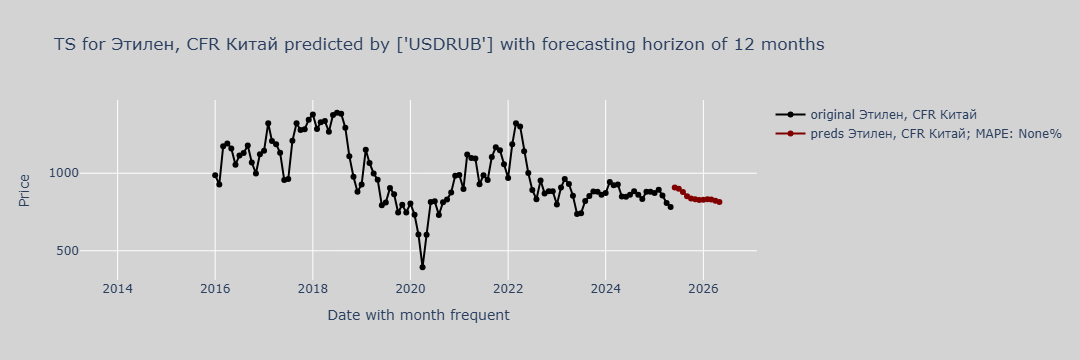

    Инфляция - Рост индекса цен производителей (RUB, eop PPI),
0                                             0.01217          
1                                             0.01125          
2                                             0.01412          
3                                             0.01266          
4                                             0.01593          
5                                             0.01218          
6                                             0.01085          
7                                            -0.00944          
8                                            -0.01155          
9                                            -0.01036          
10                                           -0.00494          
11                                           -0.00164          


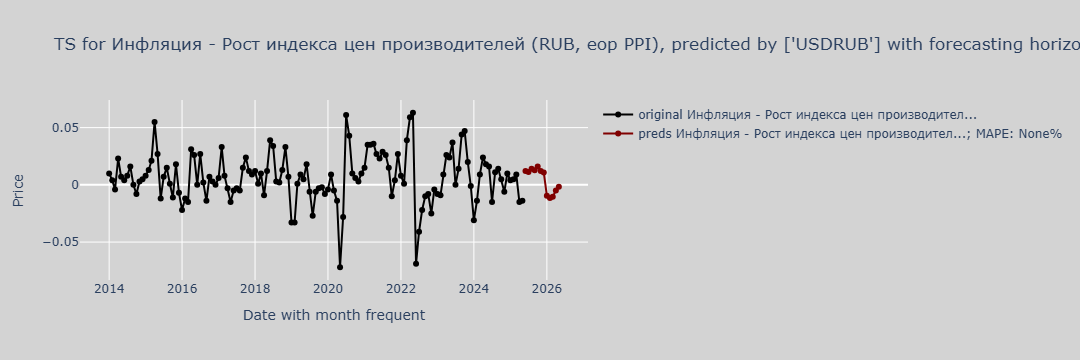

    Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),
0                                               0.392                                
1                                               0.318                                
2                                               0.216                                
3                                               0.154                                
4                                               0.207                                
5                                               0.212                                
6                                               0.208                                
7                                               0.263                                
8                                               0.279                                
9                                               0.291                                
10                                              0.186 

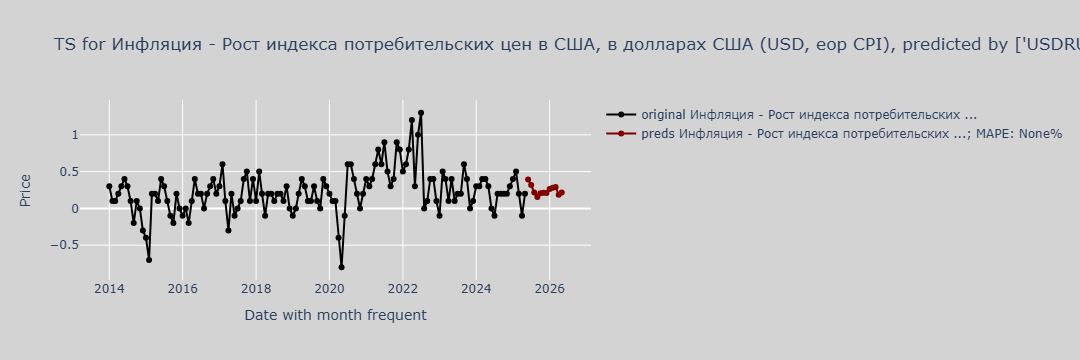

    Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),
0                                             0.00289                                
1                                             0.00308                                
2                                             0.00090                                
3                                             0.00009                                
4                                             0.00070                                
5                                             0.00139                                
6                                             0.00080                                
7                                             0.00067                                
8                                             0.00080                                
9                                             0.00039                                
10                                           -0.00044 

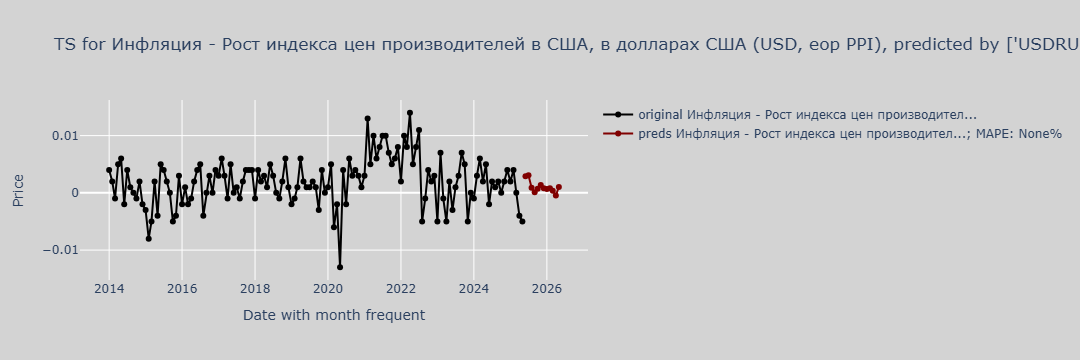

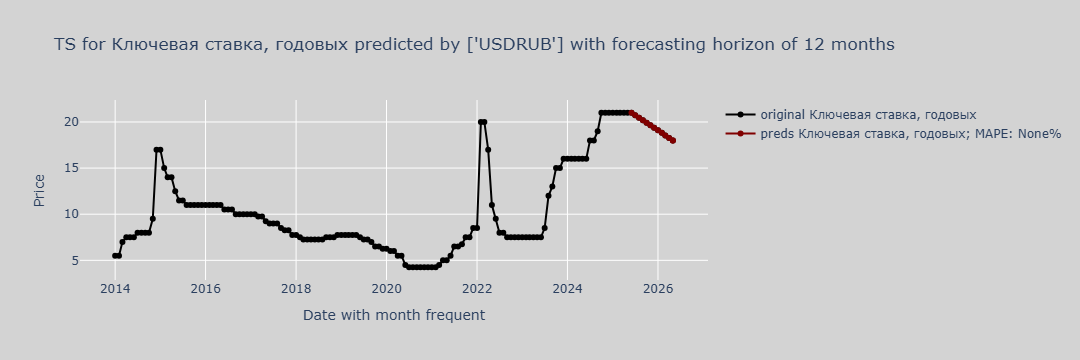

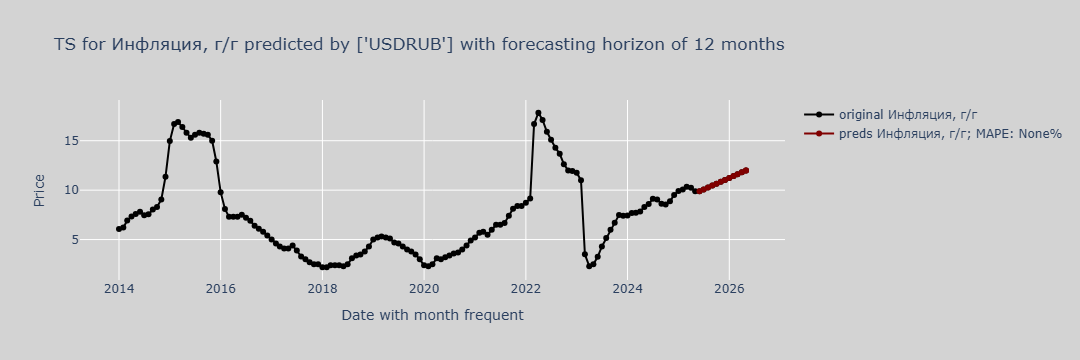

    USDRUB_norm_sum
0        204.011703
1        195.661788
2        190.997893
3        191.052156
4        191.996027
5        194.632058
6        196.647481
7        197.723681
8        201.160452
9        204.563035
10       209.759049
11       213.974192


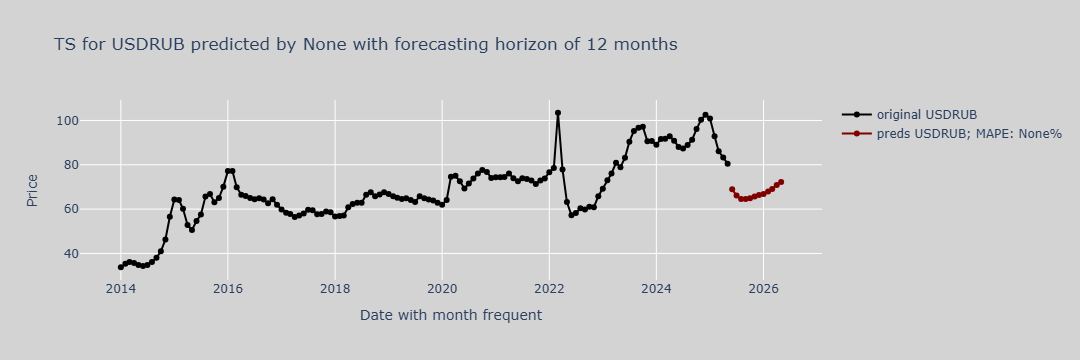

In [8]:
from sklearn.metrics import mean_absolute_percentage_error as mape


answer_last = pd.DataFrame([])
df_updated.columns = [col_name.replace("/", " ") for col_name in df_updated.columns]
mape_values = {}
processed_columns = []
for col in CATEGORY_MAP.keys():
    is_predicting_macro = col in macro_updated.columns
    df_for_col = macro_updated if is_predicting_macro else df_updated
    if col in ('Подсолнечное масло (наливом) не бутилированное, не'):
        continue
    category_to_pred = CATEGORY_MAP.get(col, "")
    if category_to_pred == "":
        continue

    cluster_preds, ts_prediction = get_prediction_for_ts(df_updated,
                                                          models[category_to_pred],
                                                          col,
                                                          MODEL_NAME_FOR_FORECASTER,
                                                          macro_updated,
                                                          past_idx,
                                                          future_idx,
                                                          CATEGORY_MAP,
                                                          BEST_PREDICTORS_FOR_INDEX,
                                                          TARGET_COL_SUFFIX,
                                                          FUTURE_FORECASTER_TS_NAME,
                                                          FUTURE_FORECASTER_TS_VALUES,
                                                          USE_FUTURE_COV,
                                                          PREDICTION_HORIZON,
                                                          IS_BACKTEST,
                                                          PREDICTOR_LAG,
                                                          new_dates
                                                        )
    processed_columns.append(col)
    answer_last = pd.concat([answer_last, ts_prediction], axis=1)
    if not is_predicting_macro:
        mape_val = mape(df_for_col.loc[ts_prediction.index][col], ts_prediction[f"{col}_preds"]) if IS_BACKTEST else -1
    mape_values[col] = mape_val
    plot_graphics_for_each_ts(df_for_col[f"{col}"],
                          ts_prediction[f"{col}_preds"],
                          None,
                          col,
                          mape_val,
                          -1,
                          BEST_PREDICTORS_FOR_INDEX[CATEGORY_MAP[col]],
                          "",
                          forecasting_horizon=PREDICTION_HORIZON)
answer_last.to_excel(f"prediction_up_to_2025_{MODEL_NAME_FOR_FORECASTER}_new_{BACKTEST_PREDICTION_RANGE}.xlsx")
pd.DataFrame([mape_values]).to_excel(f"mape_up_to_2025_{MODEL_NAME_FOR_FORECASTER}_new_{BACKTEST_PREDICTION_RANGE}.xlsx")

In [8]:
np.mean(list(mape_values.values())) # 36 rf

np.float64(0.2557746260000328)

In [7]:
np.mean(list(mape_values.values())) # 24

np.float64(0.2355687418740066)

In [12]:
np.mean(list(mape_values.values())) # 36

np.float64(0.5130650905204059)

In [10]:
np.mean(list(mape_values.values())) # 48

np.float64(0.27050711398639565)